# DeepScaleR DAPO / NGU AIME pass@k plots (grad norm 1.0 sweep)

Pulls the **grad-norm-1.0** DeepScaleR difficulty-quartile DAPO/NGU runs
described in `experiment.md` (["Additional seeds with grad norm
1.0"](../experiment.md#additional-seeds-with-grad-norm-10) and its relaunch
sections) from W&B project `ai2-llm/open_instruct_internal`, and reproduces
the same set of plots/tables as `deepscaler_ngu_dapo.ipynb` for this newer
sweep.

**Settings covered:** 3 baseline N/K configs (`N=8,K=16`, `N=4,K=32`,
`N=2,K=64`; `total_episodes=256000`, 128 completions/step, `max_grad_norm=1.0`),
each with 3 seeds, and NGU at `p in {0.5, 0.75, 0.875}` for the `N=8,K=16`
config (`p=0.5`: seeds 1-2; `p=0.75`: seeds 1-3; `p=0.875`: seeds 1 and 3 --
no seed 2, since its wandb run is a fresh in-progress continuation with no
eval data logged yet).

**2026-07-14: many seeds are still running or crashed early**, so this is no
longer a single-seed-per-setting comparison with one fixed best_step shared
across a setting. Each `RUN_SPECS` entry now carries its **own** `best_step`
(chosen by inspection of that run's own AIME+BRUMO curve, capped by however
far that run's eval history actually reaches) instead of one value per
setting. Some entries are short/noisy (e.g. `N=8,K=16` seed 3 crashed at
step 700, `NGU p=0.75` seed 3 at step 900) -- see the per-run comments in
the `RUN_SPECS` cell below for status/step counts.

**Step alignment:** these runs log an explicit `eval_step` metric (a fix
landed after the original NGU sweep -- see `experiment.md`, "Relaunch of
stalled/crashed runs"), which is already a clean multiple of
`local_eval_every=100`. We use it directly as the x-axis, no rounding
needed.

**AIME + BRUMO:** these runs eval on a 2-dataset mixer (`BRUMO 2025` +
`AIME 2025`), so the pooled `eval/pass_at_1` averages both competitions. Most
plots (training curves, point-wise pass@k) use the dataset-specific
`eval/pass_at_1/math_aime_2025` key, matching the AIME-only
`deepscaler_ngu_dapo.ipynb` notebook. The difficulty-bucket **improvement**
plots and the final summary table break both competitions out explicitly
(AIME / BRUMO / Combined sections, and AIME/BRUMO columns respectively).
`eval/prompt_solve_rate_by_index_table` is a 60-row table (`dataset_index`
0-29 = BRUMO, 30-59 = AIME, confirmed by cross-checking
`mnoukhov/aime_2025_openinstruct` against `mnoukhov/brumo_2025_openinstruct`
row counts) -- `aime_only()`/`brumo_only()` split it into two 0-29-indexed
halves before reusing the same difficulty-bucket mapping as the original
notebook (extended here to also cover BRUMO).

**Difficulty buckets** (hard / medium / easy) reuse the same initial-model
AIME solve-rate table (`w47m67sf`) as `deepscaler_ngu_dapo.ipynb`.


In [1]:
from __future__ import annotations

import json
import tempfile
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb
from datasets import load_dataset
from IPython.display import Markdown

try:
    import seaborn as sns
except ImportError as exc:
    raise ImportError("This notebook requires seaborn. Install it in the active environment before running.") from exc

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


In [2]:
PROJECT_PATH = "ai2-llm/open_instruct_internal"
DATASET_REPO = "mnoukhov/deepscaler-10k-qwen3-4b-base-32samples-quartiles"
AIME_EVAL_KEY = "eval/pass_at_1/math_aime_2025"  # dataset-specific key: these runs also eval on BRUMO 2025
BRUMO_EVAL_KEY = "eval/pass_at_1/math_brumo_2025"
EVAL_DATASETS = {"AIME": "aime", "BRUMO": "brumo"}  # display label -> column-name suffix, used by the summary table
AIME_TABLE_OFFSET = 30  # eval/prompt_solve_rate_by_index_table: dataset_index 0-29 = BRUMO, 30-59 = AIME

MAX_STEP = 2000
K_VALUES = [1, 2, 4, 8, 16, 32]

NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
OUTPUT_DIR = NOTEBOOK_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WANDB_CACHE_DIR = NOTEBOOK_DIR / ".wandb_cache"
WANDB_CACHE_DIR.mkdir(parents=True, exist_ok=True)

api = wandb.Api(timeout=90)


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/mnoukhov/.netrc.


## Run registry

Wandb run IDs recovered from each Beaker experiment's description
(`https://wandb.ai/ai2-llm/open_instruct_internal/runs/<id>`), using the
**final/relaunched** Beaker experiment for anything `experiment.md` records
as stalled/crashed (`N=4,K=32` seed 1 and both original NGU seed-1 settings
were relaunched with `--async_steps 2`; see "n4_k32 gradnorm1 stall" and "NGU
relaunch with rank-0 state-saving fix" in `experiment.md`). The original 5
seed-1 runs all finished cleanly at step 2000/2000. The 2026-07-14 seed 2/3
additions are a mix -- some finished cleanly, some are still running, some
crashed early (see the per-entry comments below) -- so `best_step` is now
chosen **per run** rather than shared across a setting's seeds.


In [3]:
RUN_SPECS = [
    {"setting": "N=8, K=16", "seed": 1, "run_id": "n9l1pfbo", "best_step": 1800,
     "beaker": "01KX6ZB67JSWDTBBH78T4JG0KV"},
    {"setting": "N=4, K=32", "seed": 1, "run_id": "1m5zen7w", "best_step": 1000,
     "beaker": "01KXE25FQ2AGZ4R8J75C5BDP9C"},  # replaces d9z062ob (2026-07-14); underlying training used --seed 4, kept in the "seed 1" slot here. Still running as of 2026-07-14, only through eval_step 1000/2000 so far.
    {"setting": "N=2, K=64", "seed": 1, "run_id": "3bfcc2f2", "best_step": 900,
     "beaker": "01KX6ZCNJ4GVGDHWP141RXET3K"},  # corrected from 1800 (inherited fixed-step value) to the run's true peak
    {"setting": "NGU p=0.5", "seed": 1, "run_id": "458k11ts", "best_step": 1200,
     "beaker": "01KX9FFKCW1NYPKAY16AXAWBM7"},  # relaunched with --async_steps 2 after rank-0 state-saving fix; finished cleanly, 2000/2000 (best_step updated 2026-07-16, was 600)
    {"setting": "NGU p=0.75", "seed": 1, "run_id": "11dc2uid", "best_step": 2000,
     "beaker": "01KX9FG1G7G4BPHAHK2DANH727"},  # relaunched with --async_steps 2 after rank-0 state-saving fix

    # --- 2026-07-14: recent seeds 2/3 (async_steps=4 default). Several still running/crashed early --
    # best_step here is each run's OWN peak within whatever eval history it has so far (no longer a
    # single fixed step shared across every seed of a setting -- some of these are incomplete/crashed).
    {"setting": "N=8, K=16", "seed": 2, "run_id": "767sjqd6", "best_step": 700,
     "beaker": "01KXMVK4YTHKJYT0E08DZDJFSE"},  # replaces 5dm52gzq (2026-07-16): 5dm52gzq was worse than seed1 on the "easy" difficulty bucket (combined AIME+BRUMO easy solve_rate 0.713 vs. 0.717 for seed1). 767sjqd6 (underlying training --seed 5) beats both (0.758 at its own easy-bucket peak, eval_step 700) -- best_step chosen for its easy-bucket peak rather than the AIME+BRUMO-combined peak. Finished cleanly, 2000/2000.
    {"setting": "N=8, K=16", "seed": 3, "run_id": "3n1jxlh1", "best_step": 700,
     "beaker": "01KXE24XX5DMZ573Z2GX378E95"},  # crashed early, only 738/2000 steps -- noisy, few eval points
    {"setting": "N=2, K=64", "seed": 2, "run_id": "tl568p6b", "best_step": 700,
     "beaker": "01KXE251AT69KM94WWAR77VAQ5"},  # still running as of 2026-07-14, 1391/2000 steps
    {"setting": "N=2, K=64", "seed": 3, "run_id": "rml761su", "best_step": 900,
     "beaker": "01KXE254WXF2QEE7W0EG3VQHV4"},  # finished cleanly, 2000/2000
    {"setting": "N=4, K=32", "seed": 2, "run_id": "617qdmx6", "best_step": 900,
     "beaker": "01KXE25C47AH6RH09QSZZ55PG3"},  # replaces 1y2hweyl (best-performing of the n4_k32 baseline seeds on the "easy" difficulty bucket -- combined AIME+BRUMO easy solve_rate 0.556 at its own best_step 1600, vs. 0.529 for seed1 and 0.453 for seed3). best_step manually set to 900 (2026-07-16, overrides the 1100-step AIME+BRUMO peak). Finished cleanly, 2000/2000.
    {"setting": "N=4, K=32", "seed": 3, "run_id": "aak27nb4", "best_step": 1000,
     "beaker": "01KXMVCH50K2898B0VDBJECY2E"},  # replaces d9z062ob (2026-07-16): d9z062ob was the clear worst of the n4_k32 baseline seeds on the "hard" difficulty bucket (combined AIME+BRUMO hard solve_rate 0.0022 at its own best_step, vs. 0.018 for seed1 and 0.020 for seed2). Underlying training --seed 5. Still running as of 2026-07-16, only through eval_step 1500/2000 so far -- best_step will need refreshing as it progresses.
    {"setting": "NGU p=0.5", "seed": 2, "run_id": "lxpogafw", "best_step": 1100,
     "beaker": "01KXE31BCDT881YTHDVF2SZX2V"},  # crashed early, 1399/2000 steps
    {"setting": "NGU p=0.5", "seed": 3, "run_id": "zg0thiuz", "best_step": 1700,
     "beaker": "01KXMWSYTD0HCE83KA7B801ENX"},  # replaces 2sti5i22 (2026-07-16); underlying training used --seed 5, async_steps=2. Finished cleanly, 2000/2000 (2026-07-17, exit code 0). best_step updated from 1000 to 1700, its true peak now that the full run is in (combined AIME+BRUMO pass_at_1 0.2542 at step 1700, vs 0.2490 at step 1000).
    {"setting": "NGU p=0.75", "seed": 2, "run_id": "wf6ttda7", "best_step": 1600,
     "beaker": "01KXE31JGTDMCB9BPFSCAH55ZH"},  # resumed since the earlier 1571-step crash; finished cleanly, 2000/2000 (2026-07-17, exit code 0) -- best_step unchanged at 1600, still its own peak. Beaker description showed a gloo comms timeout in the tail logs around exit, but that's post-completion teardown noise, not a mid-training crash (job finished 100% at step 2000/2000).
    {"setting": "NGU p=0.75", "seed": 3, "run_id": "cjr9kfxa", "best_step": 800,
     "beaker": "01KXQ4TZ69TWE7V23EE023SHYE"},  # replaces rg4fgf84 (2026-07-19): rg4fgf84 was the best of the three registered p=0.75 seeds on the "easy" difficulty bucket (combined AIME+BRUMO easy pass_at_1 0.7832 at its own best_step 1500, vs. 0.7402 for seed1 and 0.7422 for seed2). cjr9kfxa is the KL beta=0.001 variant (async_steps=2, underlying --seed 1), now finished cleanly, 2000/2000. best_step set to 800, its own combined AIME+BRUMO pass_at_1 peak (0.2589).

    # --- NGU p=0.875: previously excluded entirely (crashed relaunches). Adding the runs we have. ---
    # seed 1 is the async_steps=2 relaunch, still running.
    {"setting": "NGU p=0.875", "seed": 1, "run_id": "pq8nul2d", "best_step": 1200,
     "beaker": "01KXCH3WN17WXAWYW8FEGC4DY9"},  # finished cleanly, 2000/2000. best_step set to 1200 (2026-07-16), the run's own peak on the "hard" difficulty bucket (combined AIME+BRUMO hard solve_rate 0.182, vs. 0.181 at the AIME+BRUMO-combined peak step 1100) -- overrides the earlier combined-metric choice.
    {"setting": "NGU p=0.875", "seed": 2, "run_id": "h2q6d9fo", "best_step": 700,
     "beaker": "01KXH37D8AYKCGBMHFPJ9M62F0"},  # crashed at 1400/2000 steps (previously still running); best_step unchanged at 700, still its own peak
    {"setting": "NGU p=0.875", "seed": 3, "run_id": "ndhy0lqz", "best_step": 900,
     "beaker": "01KXJ2EJYAC6X2HNYXN9RJH7BW"},  # replaces oh1bmny3; finished cleanly, 2000/2000 (previously still running). best_step unchanged at 900, still its own peak

    # --- Ada-Est (Reinforce-Ada-Est) comparison method, N=8 K=16, max_grad_norm=1.0. These are
    # "resume" continuation runs (short remaining episode budget, total_episodes=128000 ~ 1000
    # steps) so their eval history is much shorter than the other settings' -- best_step is each
    # run's own AIME+BRUMO-combined peak within that shorter history, same convention as above. ---
    {"setting": "Sampling Curriculum (GVM/Est)", "seed": 1, "run_id": "qvce79b4", "best_step": 700,
     "beaker": "01KYDKNJ9TSPTRXYQ1Q4S9K7X3"},  # state "failed", eval history only reaches eval_step 800/1000
    {"setting": "Sampling Curriculum (GVM/Est)", "seed": 2, "run_id": "jbr3g1vs", "best_step": 800,
     "beaker": "01KYEAKKGA6N65GM69AQ0WBB62"},  # state "failed", eval history only reaches eval_step 900/1000 (2 eval points)
    {"setting": "Sampling Curriculum (GVM/Est)", "seed": 3, "run_id": "jjuzcxvf", "best_step": 800,
     "beaker": "01KYE04NF9502KDCY2NK5HQJAD"},  # state "finished", eval history reaches eval_step 1000/1000

    # --- Reinforce-Ada-Seq-Pos: seed 1 of the "Reinforce-Ada-Seq baseline" 3-seed set
    # (experiment.md, 2026-07-24 -- never_give_up=1.0, async_steps=1, active_sampling=False,
    # N=8 K=16, max_grad_norm=1.0). Crashed very early -- eval history only reaches eval_step
    # 100/2000 so far, so best_step is forced to that single point. ---
    {"setting": "Reinforce-Ada-Seq-Pos", "seed": 1, "run_id": "n8zi5rky", "best_step": 100,
     "beaker": "01KYB4MHVH8A0QTE0ZE584MFM9"},  # state "crashed", only 1 eval point logged so far
]

BASELINE_SETTING_ORDER = ["N=8, K=16", "N=4, K=32", "N=2, K=64"]
NGU_SETTING_ORDER = ["N=8, K=16", "NGU p=0.5", "NGU p=0.75", "NGU p=0.875"]
ALL_SETTING_ORDER = ["N=8, K=16", "N=4, K=32", "N=2, K=64", "NGU p=0.5", "NGU p=0.75", "NGU p=0.875", "Sampling Curriculum (GVM/Est)", "Reinforce-Ada-Seq-Pos"]
ADA_EST_SETTING_ORDER = ["Sampling Curriculum (GVM/Est)"]
ADA_EST_VS_NGU_SETTING_ORDER = ["Sampling Curriculum (GVM/Est)", "NGU p=0.5", "NGU p=0.75", "NGU p=0.875"]
REINFORCE_ADA_SEQ_POS_SETTING_ORDER = ["Reinforce-Ada-Seq-Pos"]

INITIAL_RUN_ID = "k3kgf1up"  # zero-shot Qwen3-4B-Base eval (reused from deepscaler_ngu_dapo.ipynb; same base model + AIME 2025 set)
INITIAL_RUN_NAME = "initial_eval"
DIFFICULTY_RUN_ID = "79ol8lss"  # 128-sample AIME+BRUMO solve-rate eval on Qwen3-4B-Base (2026-07-16, replaces the 64-sample w47m67sf for a less noisy hard/medium/easy split; see experiment.md)
DIFFICULTY_DATASET_REPO = "mnoukhov/aime-2025-openinstruct-qwen3-4b-base-32samples-quartiles"
BRUMO_DIFFICULTY_DATASET_REPO = "mnoukhov/brumo-2025-openinstruct-qwen3-4b-base-32samples-quartiles"
DIFFICULTY_NUM_SAMPLES = 128
DIFFICULTY_ORDER = ["hard", "medium", "easy"]

for spec in RUN_SPECS:
    spec.setdefault("excluded", False)
    spec["run_key"] = f"{spec['setting']}__seed{spec['seed']}"

print(f"{len(RUN_SPECS)} training runs registered across {len(set(s['setting'] for s in RUN_SPECS))} settings "
      f"-- best_step is chosen per-run now that seeds within a setting have differing amounts of progress")

22 training runs registered across 8 settings -- best_step is chosen per-run now that seeds within a setting have differing amounts of progress


## Download everything once

Disk-cached in `.wandb_cache/`, keyed by immutable identifiers (run_id for
full histories, the resolved wandb table file path for solve-rate tables) --
not by setting/seed label. That's the key difference from an earlier version
of this notebook, which cached by setting/seed label and went stale silently
whenever `RUN_SPECS`' `run_id`/`best_step` changed. A run_id or a specific
step's logged table never gets reassigned to different data, so caching by
those is safe. The one exception: a run's full eval/batch history is always
refetched fresh (never cached) while that run is still in W&B state
`"running"`, since its history can still grow.

In [4]:
EVAL_KEYS = [
    "_step", "eval_step", "eval/pass_at_1/math_aime_2025", "eval/pass_at_1/math_brumo_2025",
    "eval/pass_at_1_unbiased/math_aime_2025",
    "eval/pass_at_2_unbiased/math_aime_2025", "eval/pass_at_4_unbiased/math_aime_2025",
    "eval/pass_at_8_unbiased/math_aime_2025", "eval/pass_at_16_unbiased/math_aime_2025",
    "eval/pass_at_32_unbiased/math_aime_2025", "eval/prompt_solve_rate_by_index_table",
]
BATCH_KEYS = ["_step", "batch/total_prompts"] + [f"batch/nonzero_prompts/math_deepscaler_quartile{q}" for q in range(4)]
PASS_AT_K_HISTORY_COLS = {
    1: "eval/pass_at_1_unbiased/math_aime_2025", 2: "eval/pass_at_2_unbiased/math_aime_2025",
    4: "eval/pass_at_4_unbiased/math_aime_2025", 8: "eval/pass_at_8_unbiased/math_aime_2025",
    16: "eval/pass_at_16_unbiased/math_aime_2025", 32: "eval/pass_at_32_unbiased/math_aime_2025",
}


def download_run_history(run_id: str) -> dict:
    # Cached by run_id (immutable) -- but only once a run is genuinely terminal ("finished"),
    # since "crashed"/"failed"/"preempting" runs in this project routinely get resumed from
    # checkpoint into the *same* wandb run id, and their history keeps growing after that state
    # was observed. Caching on any non-"running" state (the original condition here) silently
    # froze several runs' histories at their pre-resume length -- see the "stale-cache bug" writeups
    # in experiment.md for wf6ttda7 and gz2ux8w0, both hit in practice, not hypothetical.
    cache_path = WANDB_CACHE_DIR / f"{run_id}_history.json"
    run = api.run(f"{PROJECT_PATH}/{run_id}")
    if run.state == "finished" and cache_path.exists():
        with open(cache_path) as fh:
            cached = json.load(fh)
        return {"run_id": run_id, "run_name": run.name, "state": run.state,
                "eval_rows": cached["eval_rows"], "batch_rows": cached["batch_rows"]}
    eval_rows = [row for row in run.scan_history(keys=EVAL_KEYS, page_size=1000) if row.get(AIME_EVAL_KEY) is not None]
    batch_rows = [row for row in run.scan_history(keys=BATCH_KEYS, page_size=1000) if row.get("batch/total_prompts")]
    if run.state == "finished":
        with open(cache_path, "w") as fh:
            json.dump({"eval_rows": eval_rows, "batch_rows": batch_rows}, fh)
    return {"run_id": run_id, "run_name": run.name, "state": run.state, "eval_rows": eval_rows, "batch_rows": batch_rows}


def _table_path_from_entry(entry) -> str:
    if isinstance(entry, dict) and "path" in entry:
        return entry["path"]
    return getattr(entry, "path", None) or entry["_path"]


def _read_table_file(run: wandb.apis.public.Run, table_path: str) -> pd.DataFrame:
    with tempfile.TemporaryDirectory() as tmp_dir:
        downloaded = run.file(table_path).download(root=tmp_dir, replace=True)
        with open(downloaded.name, "r") as fh:
            payload = json.load(fh)
    table_df = pd.DataFrame(payload["data"], columns=payload["columns"])
    table_df["dataset_index"] = pd.to_numeric(table_df["dataset_index"], errors="raise").astype(int)
    table_df["solve_rate"] = pd.to_numeric(table_df["solve_rate"], errors="raise").astype(float)
    return table_df.sort_values("dataset_index").reset_index(drop=True)


def download_solve_rate_table(run_id: str, *, table_entry) -> pd.DataFrame:
    # Cached by the resolved table file path -- a specific logged step's table is immutable once
    # written (even for a still-running run), so this is always safe to cache indefinitely.
    table_path = _table_path_from_entry(table_entry)
    cache_path = WANDB_CACHE_DIR / (table_path.replace("/", "__") + ".csv")
    if cache_path.exists():
        return pd.read_csv(cache_path)
    run = api.run(f"{PROJECT_PATH}/{run_id}")
    table_df = _read_table_file(run, table_path)
    table_df.to_csv(cache_path, index=False)
    return table_df


def aime_only(table_df: pd.DataFrame) -> pd.DataFrame:
    # The eval mixer is [BRUMO, AIME]: dataset_index 0-29 = BRUMO, 30-59 = AIME. Keep AIME, shift back to 0-29.
    df = table_df[table_df["dataset_index"] >= AIME_TABLE_OFFSET].copy()
    df["dataset_index"] = df["dataset_index"] - AIME_TABLE_OFFSET
    return df.reset_index(drop=True)


def brumo_only(table_df: pd.DataFrame) -> pd.DataFrame:
    # Same table, BRUMO half: dataset_index 0-29, already matching mnoukhov/brumo_2025_openinstruct's own ordering.
    return table_df[table_df["dataset_index"] < AIME_TABLE_OFFSET].reset_index(drop=True)


In [5]:
def eval_rows_to_df(eval_rows: list[dict], *, source_run_id: str) -> pd.DataFrame:
    df = pd.DataFrame(eval_rows)
    df = df.drop_duplicates(subset="eval_step", keep="last").sort_values("eval_step").reset_index(drop=True)
    df["_source_run_id"] = source_run_id
    return df


def batch_rows_to_df(batch_rows: list[dict]) -> pd.DataFrame:
    df = pd.DataFrame(batch_rows).sort_values("_step").reset_index(drop=True)
    total = df["batch/total_prompts"].replace(0, np.nan)
    for q in range(4):
        df[f"q{q}_ratio"] = df[f"batch/nonzero_prompts/math_deepscaler_quartile{q}"] / total * 100
    return df


run_data: dict[str, dict] = {}
for spec in RUN_SPECS:
    raw = download_run_history(spec["run_id"])
    eval_df = eval_rows_to_df(raw["eval_rows"], source_run_id=spec["run_id"])
    batch_df = batch_rows_to_df(raw["batch_rows"])
    run_data[spec["run_key"]] = {"spec": spec, "eval_df": eval_df, "batch_df": batch_df, "run_name": raw["run_name"]}

print(f"Downloaded/loaded history for {len(run_data)} runs")


Downloaded/loaded history for 22 runs


In [6]:
# best_row = the eval row at each setting's fixed best_step (see run registry above), not per-run early stopping.
best_step_rows = []
for run_key, d in run_data.items():
    spec = d["spec"]
    eval_df = d["eval_df"]
    matches = eval_df[eval_df["eval_step"] == spec["best_step"]]
    assert len(matches) == 1, f"expected exactly one eval row at eval_step={spec['best_step']} for {run_key}, found {len(matches)}"
    best_row = matches.iloc[0]
    d["best_row"] = best_row
    best_step_rows.append({
        "setting": spec["setting"],
        "seed": spec["seed"],
        "run_id": spec["run_id"],
        "excluded": spec["excluded"],
        "best_step": int(best_row["eval_step"]),
        "best_pass_at_1_aime": float(best_row[AIME_EVAL_KEY]),
        "best_pass_at_1_brumo": float(best_row[BRUMO_EVAL_KEY]),
        "best_pass_at_1_total": float(np.mean([best_row[AIME_EVAL_KEY], best_row[BRUMO_EVAL_KEY]])),
        "final_pass_at_1_aime": float(eval_df.iloc[-1][AIME_EVAL_KEY]),
        "final_pass_at_1_brumo": float(eval_df.iloc[-1][BRUMO_EVAL_KEY]),
    })

best_step_df = pd.DataFrame(best_step_rows)
best_step_df["setting"] = pd.Categorical(best_step_df["setting"], categories=ALL_SETTING_ORDER, ordered=True)
best_step_df = best_step_df.sort_values(["setting", "seed"]).reset_index(drop=True)
display(best_step_df)


,setting,seed,run_id,excluded,best_step,best_pass_at_1_aime,best_pass_at_1_brumo,best_pass_at_1_total,final_pass_at_1_aime,final_pass_at_1_brumo
0,"N=8, K=16",1,n9l1pfbo,False,1800,0.216667,0.290625,0.253646,0.185417,0.242708
1,"N=8, K=16",2,767sjqd6,False,700,0.196875,0.311458,0.254167,0.214583,0.255208
2,"N=8, K=16",3,3n1jxlh1,False,700,0.186458,0.285417,0.235937,0.186458,0.285417
3,"N=4, K=32",1,1m5zen7w,False,1000,0.216667,0.296875,0.256771,0.002083,0.004167
4,"N=4, K=32",2,617qdmx6,False,900,0.200000,0.294792,0.247396,0.215625,0.270833
5,"N=4, K=32",3,aak27nb4,False,1000,0.226042,0.283333,0.254688,0.181250,0.256250
6,"N=2, K=64",1,3bfcc2f2,False,900,0.213542,0.287500,0.250521,0.202083,0.258333
7,"N=2, K=64",2,tl568p6b,False,700,0.197917,0.281250,0.239583,0.000000,0.004167
8,"N=2, K=64",3,rml761su,False,900,0.196875,0.294792,0.245833,0.166667,0.259375
9,NGU p=0.5,1,458k11ts,False,1200,0.225000,0.302083,0.263542,0.170833,0.247917


In [7]:
# Solve-rate-by-index table at each run's fixed best step (for difficulty-bucket / per-dataset plots).
# Kept as two separate AIME/BRUMO halves here (un-tagged with difficulty yet -- that happens once the
# difficulty-bucket lookups are built below).
for run_key, d in run_data.items():
    best_row = d["best_row"]
    entry = best_row["eval/prompt_solve_rate_by_index_table"]
    table_df = download_solve_rate_table(best_row["_source_run_id"], table_entry=entry)
    d["best_step_solve_rate_aime_df"] = aime_only(table_df)
    d["best_step_solve_rate_brumo_df"] = brumo_only(table_df)

print("Downloaded best-step solve-rate tables for all runs (split into AIME/BRUMO halves)")


Downloaded best-step solve-rate tables for all runs (split into AIME/BRUMO halves)


## Difficulty buckets (reused from the DAPO notebook's initial-model AIME eval, now also BRUMO)

`w47m67sf` evaluated `Qwen3-4B-Base` (the same base checkpoint used here) on
a combined AIME+BRUMO set with 64 samples/prompt; its solve-rate table indexes
prompts `[AIME, BRUMO]` (`dataset_index < 30` = AIME, `>= 30` = BRUMO --
confirmed via `w47m67sf`'s own `dataset_mixer_eval_list` config, which lists
AIME before BRUMO; note this is the *opposite* order from our training runs'
`[BRUMO, AIME]` eval mixer). Each half is quartile-sorted (not by
`problem_idx`) via its own `*-qwen3-4b-base-32samples-quartiles` repo. Our
runs' AIME half (`aime_only()`) uses `mnoukhov/aime_2025_openinstruct`'s row
order, identical to `allenai/aime_2025_openinstruct`'s (`problem_idx - 1`,
verified below); the BRUMO half (`brumo_only()`) uses
`mnoukhov/brumo_2025_openinstruct`'s row order, which is `problem_idx - 1`
by construction (also verified below). We remap each of `w47m67sf`'s two
halves through `problem_idx` onto that same `dataset_index` space so the
difficulty buckets line up with our tables, then bucket AIME and BRUMO
**independently** (each split into hard/medium/easy by its own solve-rate
distribution) for the per-competition plots below. "Combined" instead pools
all 60 AIME+BRUMO prompts into one set and computes a single joint
hard/medium/easy split over that pooled set (not the two independent splits
merged together) -- pass_count/solve_rate is directly comparable across the
two competitions since both use the same `DIFFICULTY_NUM_SAMPLES`.


In [8]:
difficulty_run = api.run(f"{PROJECT_PATH}/{DIFFICULTY_RUN_ID}")
w47_table_df = download_solve_rate_table(
    DIFFICULTY_RUN_ID, table_entry=difficulty_run.summary["eval/prompt_solve_rate_by_index_table"]
)
w47_aime_df = w47_table_df[w47_table_df["dataset_index"] < 30].reset_index(drop=True)
w47_brumo_df = w47_table_df[w47_table_df["dataset_index"] >= 30].assign(dataset_index=lambda df: df["dataset_index"] - 30).reset_index(drop=True)

diff_source_aime_df = load_dataset(DIFFICULTY_DATASET_REPO, split="train").to_pandas().reset_index().rename(columns={"index": "dataset_index"})
diff_source_brumo_df = load_dataset(BRUMO_DIFFICULTY_DATASET_REPO, split="train").to_pandas().reset_index().rename(columns={"index": "dataset_index"})
mnoukhov_aime_df = load_dataset("mnoukhov/aime_2025_openinstruct", split="train").to_pandas().reset_index().rename(columns={"index": "dataset_index"})
allenai_aime_df = load_dataset("allenai/aime_2025_openinstruct", split="train").to_pandas().reset_index().rename(columns={"index": "dataset_index"})
mnoukhov_brumo_df = load_dataset("mnoukhov/brumo_2025_openinstruct", split="train").to_pandas().reset_index().rename(columns={"index": "dataset_index"})
assert (allenai_aime_df["dataset_index"] == allenai_aime_df["problem_idx"] - 1).all(), "allenai AIME ordering assumption broke"
assert (mnoukhov_aime_df["dataset_index"] == mnoukhov_aime_df["problem_idx"] - 1).all(), "mnoukhov AIME ordering assumption broke"
assert (mnoukhov_aime_df["problem"] == allenai_aime_df["problem"]).all(), "mnoukhov/allenai AIME row order mismatch"
assert (mnoukhov_brumo_df["dataset_index"] == mnoukhov_brumo_df["problem_idx"] - 1).all(), "mnoukhov BRUMO ordering assumption broke"


def remap_initial_solve(w47_half_df: pd.DataFrame, diff_source_df: pd.DataFrame) -> pd.DataFrame:
    merged = w47_half_df.merge(diff_source_df[["dataset_index", "problem_idx"]], on="dataset_index")
    remapped = merged.assign(dataset_index=lambda df: df["problem_idx"] - 1)[["dataset_index", "solve_rate"]]
    remapped["pass_count"] = (remapped["solve_rate"] * DIFFICULTY_NUM_SAMPLES).round().astype(int)
    return remapped.sort_values("dataset_index").reset_index(drop=True)


initial_solve_aime_df = remap_initial_solve(w47_aime_df, diff_source_aime_df)
initial_solve_brumo_df = remap_initial_solve(w47_brumo_df, diff_source_brumo_df)
print(f"Remapped {len(initial_solve_aime_df)} AIME + {len(initial_solve_brumo_df)} BRUMO prompts to problem_idx-1 dataset_index ordering")
display(initial_solve_aime_df.head())


Remapped 30 AIME + 30 BRUMO prompts to problem_idx-1 dataset_index ordering


,dataset_index,solve_rate,pass_count
0,0,0.507812,65
1,1,0.000000,0
2,2,0.085938,11
3,3,0.039062,5
4,4,0.046875,6


In [9]:
def assign_difficulty_buckets(initial_df: pd.DataFrame) -> pd.DataFrame:
    # hard: solve_rate == 0; remainder split evenly into easy (top half) / medium.
    # Uses the DataFrame's own row index rather than "dataset_index" (which repeats 0-29 for
    # both AIME and BRUMO), so this also works on a pooled multi-dataset frame.
    df = initial_df.copy()
    hard_mask = df["solve_rate"] <= 0
    df.loc[hard_mask, "difficulty"] = "hard"

    remainder = df.loc[~hard_mask].sort_values("solve_rate", ascending=False)
    n_easy = len(remainder) // 2 + (len(remainder) % 2)
    df.loc[remainder.index[:n_easy], "difficulty"] = "easy"
    df.loc[remainder.index[n_easy:], "difficulty"] = "medium"
    df["difficulty"] = pd.Categorical(df["difficulty"], categories=DIFFICULTY_ORDER, ordered=True)
    return df


difficulty_assignments_aime_df = assign_difficulty_buckets(initial_solve_aime_df)
difficulty_assignments_brumo_df = assign_difficulty_buckets(initial_solve_brumo_df)

# "Combined": a genuine joint hard/medium/easy split over all 60 AIME+BRUMO prompts pooled
# together (not AIME's and BRUMO's independent splits merged) -- solve_rate/pass_count are
# directly comparable across the two competitions, so this is one ranking over the pooled set.
initial_solve_combined_df = pd.concat(
    [initial_solve_aime_df.assign(dataset="AIME"), initial_solve_brumo_df.assign(dataset="BRUMO")],
    ignore_index=True,
)
difficulty_assignments_combined_df = assign_difficulty_buckets(initial_solve_combined_df)

DIFF_LOOKUP = {
    "AIME": difficulty_assignments_aime_df.set_index("dataset_index")["difficulty"],
    "BRUMO": difficulty_assignments_brumo_df.set_index("dataset_index")["difficulty"],
}
# Per-competition lookups sliced back out of the joint Combined split -- used when tagging
# Combined-mode solve-rate tables, where "dataset_index" alone is ambiguous across AIME/BRUMO.
DIFF_LOOKUP_COMBINED = {
    name: difficulty_assignments_combined_df[difficulty_assignments_combined_df["dataset"] == name]
    .set_index("dataset_index")["difficulty"]
    for name in ("AIME", "BRUMO")
}
DIFFICULTY_COUNTS = {
    "AIME": difficulty_assignments_aime_df["difficulty"].value_counts().reindex(DIFFICULTY_ORDER).astype(int),
    "BRUMO": difficulty_assignments_brumo_df["difficulty"].value_counts().reindex(DIFFICULTY_ORDER).astype(int),
    "Combined": difficulty_assignments_combined_df["difficulty"].value_counts().reindex(DIFFICULTY_ORDER).astype(int),
}
# initial_eval has no seeds to average over, so its per-bucket rate is computed once here
# and reused directly by the improvement-over-initial plots below (not folded into per_seed_df).
INITIAL_BUCKET_PASS_AT_1 = {
    "AIME": difficulty_assignments_aime_df.groupby("difficulty", observed=True)["solve_rate"].mean(),
    "BRUMO": difficulty_assignments_brumo_df.groupby("difficulty", observed=True)["solve_rate"].mean(),
    "Combined": difficulty_assignments_combined_df.groupby("difficulty", observed=True)["solve_rate"].mean(),
}


def difficulty_tick_labels(dataset_name: str) -> list[str]:
    counts = DIFFICULTY_COUNTS[dataset_name]
    return [f"{d}\n(n={counts[d]})" for d in DIFFICULTY_ORDER]


print("AIME:", DIFFICULTY_COUNTS["AIME"].to_dict())
print("BRUMO:", DIFFICULTY_COUNTS["BRUMO"].to_dict())
print("Combined:", DIFFICULTY_COUNTS["Combined"].to_dict())


AIME: {'hard': 15, 'medium': 7, 'easy': 8}
BRUMO: {'hard': 13, 'medium': 8, 'easy': 9}
Combined: {'hard': 28, 'medium': 16, 'easy': 16}


In [10]:
initial_run = api.run(f"{PROJECT_PATH}/{INITIAL_RUN_ID}")
INITIAL_PASS_AT_1 = float(initial_run.summary["eval/math_aime_2025/pass_at_1"])
INITIAL_PASS_AT_K = {k: float(initial_run.summary[f"eval/math_aime_2025/pass_at_{k}"]) for k in K_VALUES}
print(f"initial_eval pass@1 = {INITIAL_PASS_AT_1:.4f}")
print(INITIAL_PASS_AT_K)


initial_eval pass@1 = 0.0516
{1: 0.05161830357142857, 2: 0.0909148185483871, 4: 0.14438128178134435, 8: 0.19941538624519717, 16: 0.24778850494107788, 32: 0.29464285714285715}


## Plot theme

In [11]:
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="Blues",
    font="DejaVu Sans",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 8.5,
        "legend.title_fontsize": 9,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.linewidth": 0.5,
        "lines.linewidth": 2.0,
    },
)
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

baseline_palette = dict(zip(BASELINE_SETTING_ORDER, sns.color_palette("Blues", n_colors=len(BASELINE_SETTING_ORDER) + 2)[2:]))
baseline_ratio_palette = dict(zip(BASELINE_SETTING_ORDER, sns.color_palette("Greys", n_colors=len(BASELINE_SETTING_ORDER) + 3)[2:-1]))
ngu_palette = {
    "N=8, K=16": "#555555",
    "NGU p=0.5": "#9ecae1",
    "NGU p=0.75": "#4292c6",
    "NGU p=0.875": "#2171b5",
}

# For the combined NGU ratio plot: baselines in greyscale, NGU p-sweep in bluescale.
NGU_RATIO_BASELINE_SETTINGS = ["N=8, K=16", "N=4, K=32", "N=2, K=64"]
NGU_RATIO_SETTING_ORDER = NGU_RATIO_BASELINE_SETTINGS + ["NGU p=0.5", "NGU p=0.75", "NGU p=0.875"]
ngu_ratio_palette = dict(zip(
    NGU_RATIO_BASELINE_SETTINGS,
    sns.color_palette("Greys", n_colors=len(NGU_RATIO_BASELINE_SETTINGS) + 3)[2:-1],
))
ngu_ratio_palette.update({
    "NGU p=0.5": "#9ecae1",
    "NGU p=0.75": "#4292c6",
    "NGU p=0.875": "#2171b5",
})

# Ada-Est comparison: distinct orange vs. the NGU p-sweep's blues.
ada_est_vs_ngu_palette = {
    "Sampling Curriculum (GVM/Est)": "#e6550d",
    "NGU p=0.5": "#9ecae1",
    "NGU p=0.75": "#4292c6",
    "NGU p=0.875": "#2171b5",
}


## `eval/pass_at_1` over training, mean +/- SEM across seeds

Full trajectories (not point-wise), plotted against `eval_step`. Every
setting now has 2-3 seeds (see run registry above), so these are mean +/-
SEM bands across seeds rather than single lines.


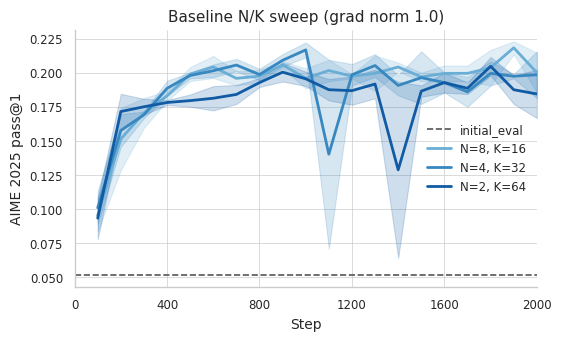

In [12]:
def build_pass_at_1_long_df(setting_order: list[str]) -> pd.DataFrame:
    rows = []
    for d in run_data.values():
        spec = d["spec"]
        if spec["excluded"] or spec["setting"] not in setting_order:
            continue
        eval_df = d["eval_df"]
        for _, row in eval_df.iterrows():
            rows.append({"setting": spec["setting"], "seed": spec["seed"], "Step": int(row["eval_step"]), "value": float(row[AIME_EVAL_KEY])})
    df = pd.DataFrame(rows)
    df["setting"] = pd.Categorical(df["setting"], categories=setting_order, ordered=True)
    return df.sort_values(["setting", "seed", "Step"]).reset_index(drop=True)


def plot_pass_at_1_over_steps(df: pd.DataFrame, setting_order: list[str], palette: dict, out_name: str, title: str | None = None):
    fig, ax = plt.subplots(figsize=(5.5, 3.3), constrained_layout=True)
    ax.axhline(INITIAL_PASS_AT_1, color="#555555", linestyle="--", linewidth=1.2, label=INITIAL_RUN_NAME, zorder=1)
    sns.lineplot(
        data=df, x="Step", y="value", hue="setting", hue_order=setting_order, palette=palette,
        errorbar="se", estimator="mean", ax=ax,
    )
    ax.set_xlabel("Step")
    ax.set_ylabel("AIME 2025 pass@1")
    ax.set_xlim(0, MAX_STEP)
    ax.set_xticks(range(0, MAX_STEP + 100, 400))
    if title:
        ax.set_title(title)
    ax.legend(frameon=False, loc="best")
    sns.despine(ax=ax)
    fig.savefig(OUTPUT_DIR / out_name, bbox_inches="tight")
    return fig, ax


baseline_pass_at_1_df = build_pass_at_1_long_df(BASELINE_SETTING_ORDER)
plot_pass_at_1_over_steps(baseline_pass_at_1_df, BASELINE_SETTING_ORDER, baseline_palette,
                           "deepscaler_gradnorm1_baseline_aime_2025_pass_at_1.pdf", "Baseline N/K sweep (grad norm 1.0)")
plt.show()


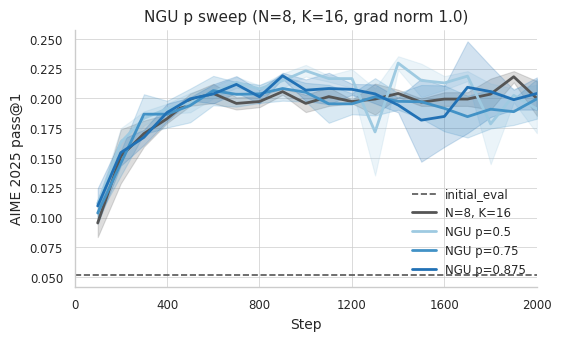

In [13]:
ngu_pass_at_1_df = build_pass_at_1_long_df(NGU_SETTING_ORDER)
plot_pass_at_1_over_steps(ngu_pass_at_1_df, NGU_SETTING_ORDER, ngu_palette,
                           "deepscaler_gradnorm1_ngu_aime_2025_pass_at_1.pdf", "NGU p sweep (N=8, K=16, grad norm 1.0)")
plt.show()


## Point-wise pass@k, at each run's own best step

Read off pass@k at each run's own best step from the run registry above,
then averaged (mean +/- SEM) across the seeds within each setting.


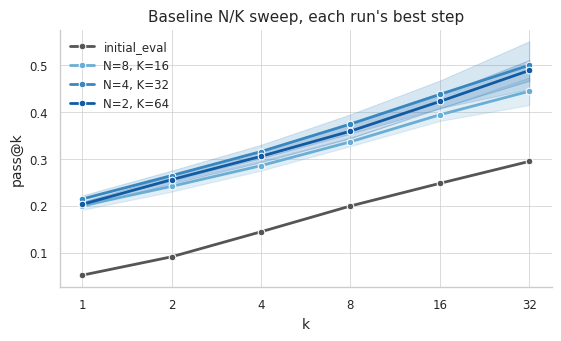

In [14]:
def build_pass_at_k_df(setting_order: list[str]) -> pd.DataFrame:
    rows = [{"setting": INITIAL_RUN_NAME, "k": k, "value": v} for k, v in INITIAL_PASS_AT_K.items()]
    for d in run_data.values():
        spec, best_row = d["spec"], d["best_row"]
        if spec["excluded"] or spec["setting"] not in setting_order:
            continue
        for k, col in PASS_AT_K_HISTORY_COLS.items():
            rows.append({"setting": spec["setting"], "seed": spec["seed"], "k": k, "value": float(best_row[col])})
    df = pd.DataFrame(rows)
    label_order = [INITIAL_RUN_NAME, *setting_order]
    df["setting"] = pd.Categorical(df["setting"], categories=label_order, ordered=True)
    return df.sort_values(["setting", "k"]).reset_index(drop=True)


def plot_pass_at_k(df: pd.DataFrame, setting_order: list[str], palette: dict, out_name: str, title: str | None = None):
    label_order = [INITIAL_RUN_NAME, *setting_order]
    full_palette = {INITIAL_RUN_NAME: "#555555", **palette}
    fig, ax = plt.subplots(figsize=(5.5, 3.3), constrained_layout=True)
    sns.lineplot(
        data=df, x="k", y="value", hue="setting", hue_order=label_order, palette=full_palette,
        errorbar="se", estimator="mean", marker="o", ax=ax,
    )
    ax.set_xlabel("k")
    ax.set_ylabel("pass@k")
    ax.set_xscale("log", base=2)
    ax.set_xticks(K_VALUES)
    ax.set_xticklabels([str(k) for k in K_VALUES])
    if title:
        ax.set_title(title)
    ax.legend(frameon=False, loc="best")
    sns.despine(ax=ax)
    fig.savefig(OUTPUT_DIR / out_name, bbox_inches="tight")
    return fig, ax


baseline_pass_at_k_df = build_pass_at_k_df(BASELINE_SETTING_ORDER)
plot_pass_at_k(baseline_pass_at_k_df, BASELINE_SETTING_ORDER, baseline_palette,
               "deepscaler_gradnorm1_baseline_aime_2025_best_step_pass_at_k.pdf", "Baseline N/K sweep, each run's best step")
plt.show()


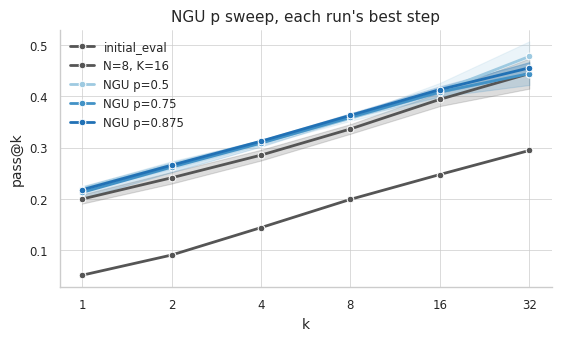

In [15]:
ngu_pass_at_k_df = build_pass_at_k_df(NGU_SETTING_ORDER)
plot_pass_at_k(ngu_pass_at_k_df, NGU_SETTING_ORDER, ngu_palette,
               "deepscaler_gradnorm1_ngu_aime_2025_best_step_pass_at_k.pdf", "NGU p sweep, each run's best step")
plt.show()


## Point-wise `pass_at_1_by_difficulty`, at each setting's fixed best step

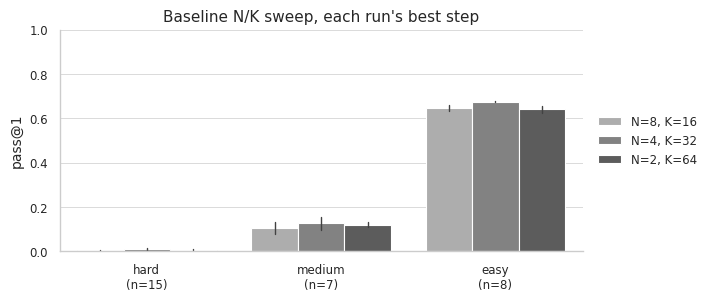

In [16]:
TABLE_ATTR = {"AIME": "best_step_solve_rate_aime_df", "BRUMO": "best_step_solve_rate_brumo_df"}


def tagged_solve_df(d: dict, dataset_name: str) -> pd.DataFrame:
    # dataset_name is "AIME", "BRUMO", or "Combined" (AIME rows + BRUMO rows pooled together,
    # tagged by the *joint* hard/medium/easy split in DIFF_LOOKUP_COMBINED -- not each
    # competition's independent split).
    if dataset_name == "Combined":
        rows = []
        for name in ("AIME", "BRUMO"):
            table_df = d[TABLE_ATTR[name]].copy()
            table_df["difficulty"] = table_df["dataset_index"].map(DIFF_LOOKUP_COMBINED[name]).astype(
                pd.CategoricalDtype(categories=DIFFICULTY_ORDER, ordered=True)
            )
            rows.append(table_df)
        return pd.concat(rows, ignore_index=True)
    table_df = d[TABLE_ATTR[dataset_name]].copy()
    table_df["difficulty"] = table_df["dataset_index"].map(DIFF_LOOKUP[dataset_name]).astype(
        pd.CategoricalDtype(categories=DIFFICULTY_ORDER, ordered=True)
    )
    return table_df


def build_bucket_accuracy_df(setting_order: list[str], dataset_name: str = "AIME") -> pd.DataFrame:
    rows = []
    for d in run_data.values():
        spec = d["spec"]
        if spec["excluded"] or spec["setting"] not in setting_order:
            continue
        table_df = tagged_solve_df(d, dataset_name).copy()
        table_df["setting"] = spec["setting"]
        table_df["seed"] = spec["seed"]
        rows.append(table_df[["dataset_index", "solve_rate", "difficulty", "setting", "seed"]])

    solve_df = pd.concat(rows, ignore_index=True)
    # per-seed mean over prompts in a bucket, then mean +/- sem across seeds
    per_seed = solve_df.groupby(["setting", "seed", "difficulty"], observed=True)["solve_rate"].mean().reset_index()
    per_seed["setting"] = pd.Categorical(per_seed["setting"], categories=setting_order, ordered=True)
    return per_seed.rename(columns={"solve_rate": "pass_at_1"})


def plot_bucket_accuracy(per_seed_df: pd.DataFrame, setting_order: list[str], palette: dict, out_name: str, title: str | None = None, dataset_name: str = "AIME"):
    fig, ax = plt.subplots(figsize=(7.0, 2.9), constrained_layout=True)
    sns.barplot(
        data=per_seed_df, x="difficulty", y="pass_at_1", hue="setting", hue_order=setting_order,
        palette=palette, order=DIFFICULTY_ORDER, errorbar="se", err_kws={"linewidth": 1.0}, ax=ax,
    )
    ax.set_xlabel("")
    ax.set_xticks(range(len(DIFFICULTY_ORDER)))
    ax.set_xticklabels(difficulty_tick_labels(dataset_name))
    ax.set_ylabel("pass@1")
    ax.set_ylim(0, 1)
    if title:
        ax.set_title(title)
    ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    sns.despine(ax=ax)
    fig.savefig(OUTPUT_DIR / out_name, bbox_inches="tight")
    return fig, ax


baseline_bucket_df = build_bucket_accuracy_df(BASELINE_SETTING_ORDER, "AIME")
plot_bucket_accuracy(baseline_bucket_df, BASELINE_SETTING_ORDER, baseline_ratio_palette,
                      "deepscaler_gradnorm1_baseline_pass_at_1_by_difficulty.pdf", "Baseline N/K sweep, each run's best step")
plt.show()


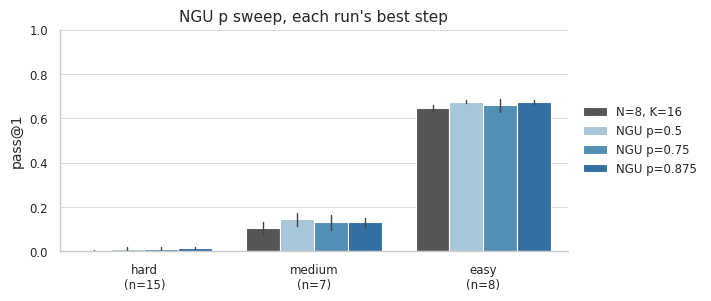

In [17]:
ngu_bucket_df = build_bucket_accuracy_df(NGU_SETTING_ORDER, "AIME")
plot_bucket_accuracy(ngu_bucket_df, NGU_SETTING_ORDER, ngu_palette,
                      "deepscaler_gradnorm1_ngu_pass_at_1_by_difficulty.pdf", "NGU p sweep, each run's best step")
plt.show()


### Sampling Curriculum (GVM/Est) vs. NGU p sweep

Same point-wise `pass_at_1_by_difficulty` comparison as above, but swapping in the `Sampling Curriculum (GVM/Est)` runs (3 seeds) against the three NGU p-sweep settings (`p=0.5`, `p=0.75`, `p=0.875`) instead of the `N=8, K=16` baseline.


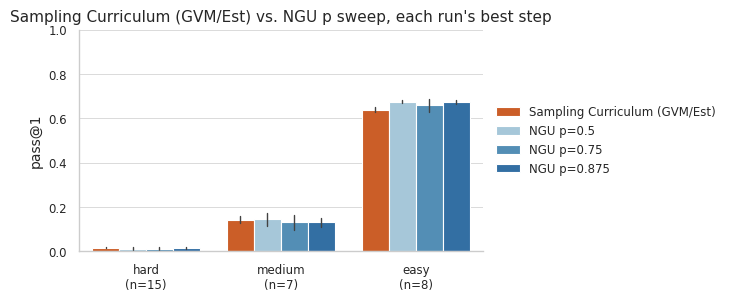

In [18]:
ada_est_bucket_df = build_bucket_accuracy_df(ADA_EST_VS_NGU_SETTING_ORDER, "AIME")
plot_bucket_accuracy(ada_est_bucket_df, ADA_EST_VS_NGU_SETTING_ORDER, ada_est_vs_ngu_palette,
                      "deepscaler_gradnorm1_ada_est_vs_ngu_pass_at_1_by_difficulty.pdf",
                      "Sampling Curriculum (GVM/Est) vs. NGU p sweep, each run's best step")
plt.show()


### Improvement over `initial_eval`, by difficulty bucket

Same plot family as `deepscaler_ngu_dapo.ipynb`, but repeated for AIME,
BRUMO, and the two pooled together ("Combined") -- these training runs
logged both competitions, so we're no longer limited to AIME-only.


In [18]:
def plot_bucket_improvement(per_seed_df: pd.DataFrame, setting_order: list[str], palette: dict, out_name: str, title: str | None = None, dataset_name: str = "AIME", show_ylabel: bool = True, fontsize_scale: float = 1.0):
    initial_lookup = INITIAL_BUCKET_PASS_AT_1[dataset_name]
    improvement_df = per_seed_df.copy()
    improvement_df["improvement"] = (
        improvement_df["pass_at_1"].astype(float) - improvement_df["difficulty"].map(initial_lookup).astype(float)
    ) * 100
    improvement_df["setting"] = pd.Categorical(improvement_df["setting"], categories=setting_order, ordered=True)

    rc_overrides = {}
    if fontsize_scale != 1.0:
        rc_overrides = {
            "axes.labelsize": 10 * fontsize_scale,
            "axes.titlesize": 11 * fontsize_scale,
            "legend.fontsize": 8.5 * fontsize_scale,
            "legend.title_fontsize": 9 * fontsize_scale,
            "xtick.labelsize": 8.5 * fontsize_scale,
            "ytick.labelsize": 8.5 * fontsize_scale,
        }
    with plt.rc_context(rc_overrides):
        fig, ax = plt.subplots(figsize=(7.0, 2.9), constrained_layout=True)
        sns.barplot(
            data=improvement_df, x="difficulty", y="improvement", hue="setting", hue_order=setting_order,
            palette=palette, order=DIFFICULTY_ORDER, errorbar="se", err_kws={"linewidth": 1.0}, ax=ax,
        )
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xlabel("")
        ax.set_xticks(range(len(DIFFICULTY_ORDER)))
        ax.set_xticklabels(difficulty_tick_labels(dataset_name))
        ax.set_ylabel("pass@1 (%) vs. initial_eval" if show_ylabel else "")
        if title:
            ax.set_title(title)
        ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
        sns.despine(ax=ax)
        fig.savefig(OUTPUT_DIR / out_name, bbox_inches="tight")
    return fig, ax, improvement_df

#### AIME 2025

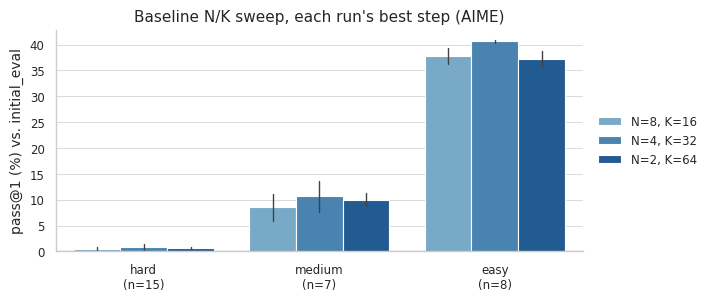

difficulty,hard,medium,easy
setting,,,
"N=8, K=16",0.555556,8.556548,37.760417
"N=4, K=32",0.902778,10.639881,40.625000
"N=2, K=64",0.694444,10.044643,37.239583


In [20]:
baseline_bucket_aime_df = build_bucket_accuracy_df(BASELINE_SETTING_ORDER, "AIME")
_, _, baseline_improvement_aime_df = plot_bucket_improvement(
    baseline_bucket_aime_df, BASELINE_SETTING_ORDER, baseline_palette,
    "deepscaler_gradnorm1_baseline_pass_at_1_improvement_by_difficulty_aime.pdf", "Baseline N/K sweep, each run's best step (AIME)",
    dataset_name="AIME",
)
plt.show()
display(baseline_improvement_aime_df.groupby(["setting", "difficulty"], observed=True)["improvement"].mean().unstack())


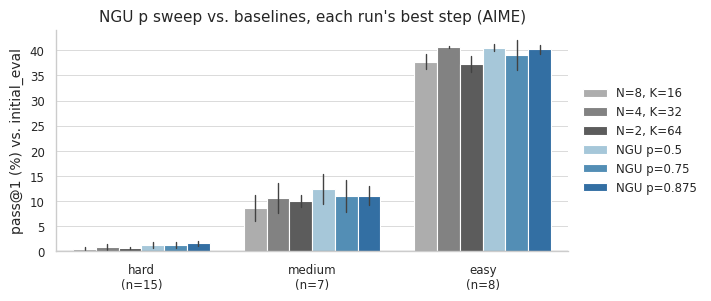

difficulty,hard,medium,easy
setting,,,
"N=8, K=16",0.555556,8.556548,37.760417
"N=4, K=32",0.902778,10.639881,40.625000
"N=2, K=64",0.694444,10.044643,37.239583
NGU p=0.5,1.250000,12.425595,40.494792
NGU p=0.75,1.250000,11.086310,39.062500
NGU p=0.875,1.666667,11.086310,40.234375


In [21]:
ngu_bucket_aime_df = build_bucket_accuracy_df(NGU_RATIO_SETTING_ORDER, "AIME")
_, _, ngu_improvement_aime_df = plot_bucket_improvement(
    ngu_bucket_aime_df, NGU_RATIO_SETTING_ORDER, ngu_ratio_palette,
    "deepscaler_gradnorm1_ngu_pass_at_1_improvement_by_difficulty_aime.pdf", "NGU p sweep vs. baselines, each run's best step (AIME)",
    dataset_name="AIME",
)
plt.show()
display(ngu_improvement_aime_df.groupby(["setting", "difficulty"], observed=True)["improvement"].mean().unstack())


### Sampling Curriculum (GVM/Est) vs. NGU p sweep, improvement over `initial_eval`

Same `improvement` framing as above (pass@1 minus `initial_eval`'s pass@1 in that difficulty bucket), for `Sampling Curriculum (GVM/Est)` against the three NGU p-sweep settings (AIME).


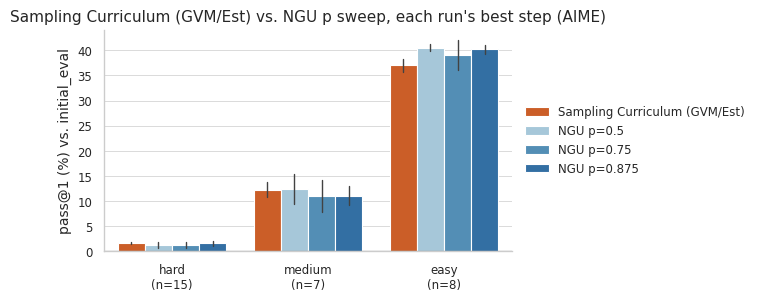

difficulty,hard,medium,easy
setting,,,
Sampling Curriculum (GVM/Est),1.666667,12.276786,36.979167
NGU p=0.5,1.250000,12.425595,40.494792
NGU p=0.75,1.250000,11.086310,39.062500
NGU p=0.875,1.666667,11.086310,40.234375


In [22]:
ada_est_bucket_aime_df = build_bucket_accuracy_df(ADA_EST_VS_NGU_SETTING_ORDER, "AIME")
_, _, ada_est_improvement_aime_df = plot_bucket_improvement(
    ada_est_bucket_aime_df, ADA_EST_VS_NGU_SETTING_ORDER, ada_est_vs_ngu_palette,
    "deepscaler_gradnorm1_ada_est_vs_ngu_pass_at_1_improvement_by_difficulty_aime.pdf",
    "Sampling Curriculum (GVM/Est) vs. NGU p sweep, each run's best step (AIME)",
    dataset_name="AIME",
)
plt.show()
display(ada_est_improvement_aime_df.groupby(["setting", "difficulty"], observed=True)["improvement"].mean().unstack())


#### BRUMO 2025

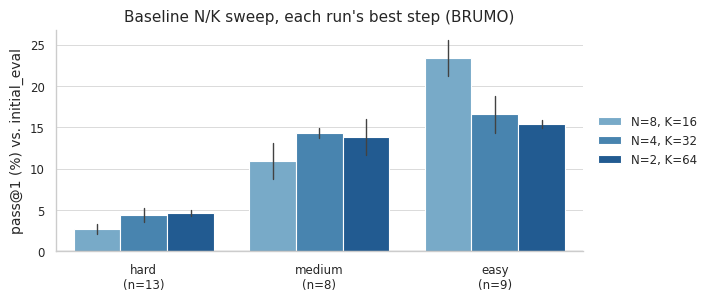

difficulty,hard,medium,easy
setting,,,
"N=8, K=16",2.724359,10.970052,23.379630
"N=4, K=32",4.407051,14.355469,16.550926
"N=2, K=64",4.647436,13.834635,15.393519


In [23]:
baseline_bucket_brumo_df = build_bucket_accuracy_df(BASELINE_SETTING_ORDER, "BRUMO")
_, _, baseline_improvement_brumo_df = plot_bucket_improvement(
    baseline_bucket_brumo_df, BASELINE_SETTING_ORDER, baseline_palette,
    "deepscaler_gradnorm1_baseline_pass_at_1_improvement_by_difficulty_brumo.pdf", "Baseline N/K sweep, each run's best step (BRUMO)",
    dataset_name="BRUMO",
)
plt.show()
display(baseline_improvement_brumo_df.groupby(["setting", "difficulty"], observed=True)["improvement"].mean().unstack())


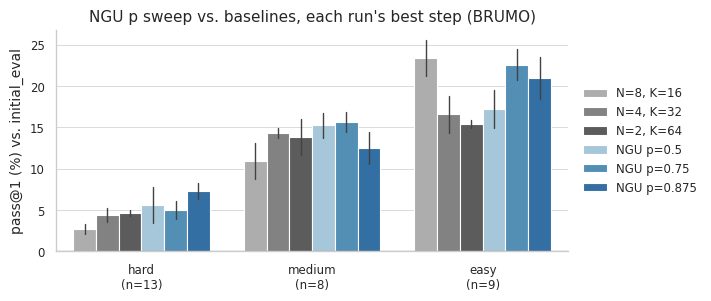

difficulty,hard,medium,easy
setting,,,
"N=8, K=16",2.724359,10.970052,23.379630
"N=4, K=32",4.407051,14.355469,16.550926
"N=2, K=64",4.647436,13.834635,15.393519
NGU p=0.5,5.608974,15.266927,17.245370
NGU p=0.75,4.967949,15.657552,22.569444
NGU p=0.875,7.291667,12.532552,20.949074


In [24]:
ngu_bucket_brumo_df = build_bucket_accuracy_df(NGU_RATIO_SETTING_ORDER, "BRUMO")
_, _, ngu_improvement_brumo_df = plot_bucket_improvement(
    ngu_bucket_brumo_df, NGU_RATIO_SETTING_ORDER, ngu_ratio_palette,
    "deepscaler_gradnorm1_ngu_pass_at_1_improvement_by_difficulty_brumo.pdf", "NGU p sweep vs. baselines, each run's best step (BRUMO)",
    dataset_name="BRUMO",
)
plt.show()
display(ngu_improvement_brumo_df.groupby(["setting", "difficulty"], observed=True)["improvement"].mean().unstack())


#### Combined (AIME + BRUMO)

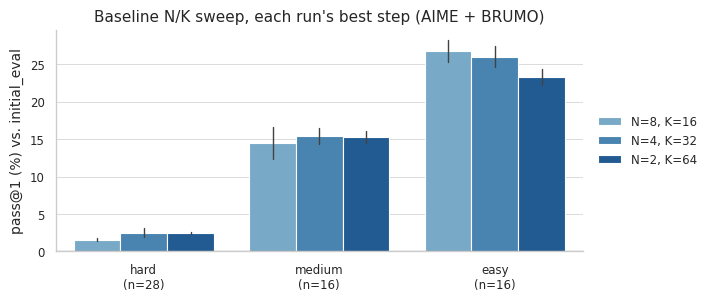

difficulty,hard,medium,easy
setting,,,
"N=8, K=16",1.562500,14.501953,26.757812
"N=4, K=32",2.529762,15.413411,26.041667
"N=2, K=64",2.529762,15.283203,23.307292


In [25]:
baseline_bucket_combined_df = build_bucket_accuracy_df(BASELINE_SETTING_ORDER, "Combined")
_, _, baseline_improvement_combined_df = plot_bucket_improvement(
    baseline_bucket_combined_df, BASELINE_SETTING_ORDER, baseline_palette,
    "deepscaler_gradnorm1_baseline_pass_at_1_improvement_by_difficulty_combined.pdf", "Baseline N/K sweep, each run's best step (AIME + BRUMO)",
    dataset_name="Combined",
)
plt.show()
display(baseline_improvement_combined_df.groupby(["setting", "difficulty"], observed=True)["improvement"].mean().unstack())


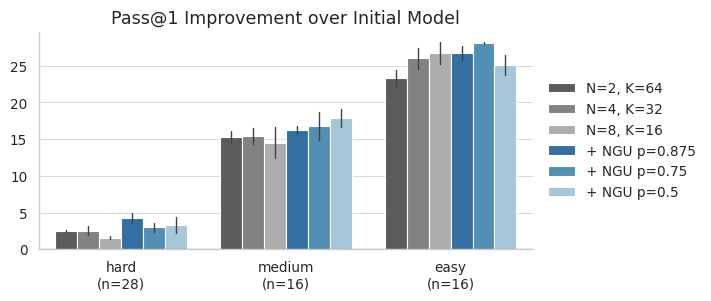

difficulty,hard,medium,easy
setting,,,
"N=2, K=64",2.529762,15.283203,23.307292
"N=4, K=32",2.529762,15.413411,26.041667
"N=8, K=16",1.562500,14.501953,26.757812
+ NGU p=0.875,4.278274,16.259766,26.757812
+ NGU p=0.75,2.976190,16.780599,28.125000
+ NGU p=0.5,3.273810,17.887370,25.130208


In [21]:
NGU_RATIO_SETTING_ORDER_COMBINED = ["N=2, K=64", "N=4, K=32", "N=8, K=16", "+ NGU p=0.875", "+ NGU p=0.75", "+ NGU p=0.5"]
NGU_RATIO_RENAME_COMBINED = {"NGU p=0.5": "+ NGU p=0.5", "NGU p=0.75": "+ NGU p=0.75", "NGU p=0.875": "+ NGU p=0.875"}
ngu_ratio_palette_combined = {NGU_RATIO_RENAME_COMBINED.get(k, k): v for k, v in ngu_ratio_palette.items()}

ngu_bucket_combined_df = build_bucket_accuracy_df(NGU_RATIO_SETTING_ORDER, "Combined")
ngu_bucket_combined_df["setting"] = ngu_bucket_combined_df["setting"].astype(str).replace(NGU_RATIO_RENAME_COMBINED)
_, _, ngu_improvement_combined_df = plot_bucket_improvement(
    ngu_bucket_combined_df, NGU_RATIO_SETTING_ORDER_COMBINED, ngu_ratio_palette_combined,
    "deepscaler_gradnorm1_ngu_pass_at_1_improvement_by_difficulty_combined.pdf", "Pass@1 Improvement over Initial Model",
    dataset_name="Combined", show_ylabel=False, fontsize_scale=1.15,
)
plt.show()
display(ngu_improvement_combined_df.groupby(["setting", "difficulty"], observed=True)["improvement"].mean().unstack())

from deepscaler_blog_plotly import write_deepscaler_improvement_by_difficulty

write_deepscaler_improvement_by_difficulty(
    improvement_df=ngu_improvement_combined_df,
    setting_order=NGU_RATIO_SETTING_ORDER_COMBINED,
    palette=ngu_ratio_palette_combined,
    difficulty_order=DIFFICULTY_ORDER,
    difficulty_labels=difficulty_tick_labels("Combined"),
    output_dir=Path("/home/mnoukhov/mnoukhov.github.io/data/ngu"),
)

### LaTeX tables: pass@1 improvement over `initial_eval` (NGU p sweep vs. baselines, Combined AIME+BRUMO)

In [25]:
# By difficulty bucket (easy, medium, hard), with an overall "Total" column: a prompt-count-weighted
# average of the three buckets (an unweighted mean would over-weight the smaller buckets), computed
# per seed so Total gets its own correct std dev (not derived from the per-bucket std devs).
DIFFICULTY_ORDER_DISPLAY = ["easy", "medium", "hard"]
bucket_wide = ngu_improvement_combined_df.pivot(index=["setting", "seed"], columns="difficulty", values="improvement")[DIFFICULTY_ORDER_DISPLAY]
bucket_weights = DIFFICULTY_COUNTS["Combined"]
bucket_wide["Total"] = bucket_wide[DIFFICULTY_ORDER_DISPLAY].mul(bucket_weights).sum(axis=1) / bucket_weights.sum()

ngu_bucket_mean = bucket_wide.groupby(level="setting", observed=True).mean().reindex(NGU_RATIO_SETTING_ORDER_COMBINED)
ngu_bucket_std = bucket_wide.groupby(level="setting", observed=True).std().reindex(NGU_RATIO_SETTING_ORDER_COMBINED)
ngu_bucket_table_combined = ngu_bucket_mean.round(1).astype(str) + r" $\pm$ " + ngu_bucket_std.round(1).astype(str)
display(ngu_bucket_table_combined)

print(
    ngu_bucket_table_combined
    .rename(columns=str.capitalize)
    .rename_axis(index=None, columns=None)
    .to_latex(escape=False, column_format="l" + "c" * len(ngu_bucket_table_combined.columns))
)

difficulty,easy,medium,hard,Total
setting,,,,
"N=2, K=64",23.3 $\pm$ 1.9,15.3 $\pm$ 1.5,2.5 $\pm$ 0.2,11.5 $\pm$ 0.5
"N=4, K=32",26.0 $\pm$ 2.5,15.4 $\pm$ 1.8,2.5 $\pm$ 1.1,12.2 $\pm$ 0.5
"N=8, K=16",26.8 $\pm$ 2.6,14.5 $\pm$ 3.6,1.6 $\pm$ 0.3,11.7 $\pm$ 1.0
+ NGU p=0.875,26.8 $\pm$ 1.7,16.3 $\pm$ 0.9,4.3 $\pm$ 1.2,13.5 $\pm$ 0.6
+ NGU p=0.75,28.1 $\pm$ 0.2,16.8 $\pm$ 3.3,3.0 $\pm$ 1.2,13.4 $\pm$ 0.7
+ NGU p=0.5,25.1 $\pm$ 2.3,17.9 $\pm$ 2.2,3.3 $\pm$ 1.9,13.0 $\pm$ 0.6


\begin{tabular}{lcccc}
\toprule
 & Easy & Medium & Hard & Total \\
\midrule
N=2, K=64 & 23.3 $\pm$ 1.9 & 15.3 $\pm$ 1.5 & 2.5 $\pm$ 0.2 & 11.5 $\pm$ 0.5 \\
N=4, K=32 & 26.0 $\pm$ 2.5 & 15.4 $\pm$ 1.8 & 2.5 $\pm$ 1.1 & 12.2 $\pm$ 0.5 \\
N=8, K=16 & 26.8 $\pm$ 2.6 & 14.5 $\pm$ 3.6 & 1.6 $\pm$ 0.3 & 11.7 $\pm$ 1.0 \\
+ NGU p=0.875 & 26.8 $\pm$ 1.7 & 16.3 $\pm$ 0.9 & 4.3 $\pm$ 1.2 & 13.5 $\pm$ 0.6 \\
+ NGU p=0.75 & 28.1 $\pm$ 0.2 & 16.8 $\pm$ 3.3 & 3.0 $\pm$ 1.2 & 13.4 $\pm$ 0.7 \\
+ NGU p=0.5 & 25.1 $\pm$ 2.3 & 17.9 $\pm$ 2.2 & 3.3 $\pm$ 1.9 & 13.0 $\pm$ 0.6 \\
\bottomrule
\end{tabular}



In [27]:
# By dataset (AIME 25 / BRUMO 25 / Overall), non-bucketed -- absolute pass@1, not improvement over initial_eval
def build_dataset_accuracy_df(setting_order: list[str], dataset_name: str = "AIME") -> pd.DataFrame:
    rows = []
    for d in run_data.values():
        spec = d["spec"]
        if spec["excluded"] or spec["setting"] not in setting_order:
            continue
        if dataset_name == "Combined":
            table_df = pd.concat([
                d[TABLE_ATTR["AIME"]][["dataset_index", "solve_rate"]],
                d[TABLE_ATTR["BRUMO"]][["dataset_index", "solve_rate"]],
            ], ignore_index=True)
        else:
            table_df = d[TABLE_ATTR[dataset_name]][["dataset_index", "solve_rate"]].copy()
        table_df["setting"] = spec["setting"]
        table_df["seed"] = spec["seed"]
        rows.append(table_df)

    solve_df = pd.concat(rows, ignore_index=True)
    per_seed = solve_df.groupby(["setting", "seed"], observed=True)["solve_rate"].mean().reset_index()
    per_seed["setting"] = pd.Categorical(per_seed["setting"], categories=setting_order, ordered=True)
    return per_seed.rename(columns={"solve_rate": "pass_at_1"})


DATASET_DISPLAY_NAMES = {"AIME": "AIME 25", "BRUMO": "BRUMO 25", "Combined": "Overall"}
DATASET_DISPLAY_ORDER = ["AIME 25", "BRUMO 25", "Overall"]

dataset_rows = []
for dataset_name in ("AIME", "BRUMO", "Combined"):
    per_seed_df = build_dataset_accuracy_df(NGU_RATIO_SETTING_ORDER, dataset_name)
    per_seed_df["pass_at_1_pct"] = per_seed_df["pass_at_1"].astype(float) * 100
    per_seed_df["setting"] = per_seed_df["setting"].astype(str).replace(NGU_RATIO_RENAME_COMBINED)
    per_seed_df["dataset"] = DATASET_DISPLAY_NAMES[dataset_name]
    dataset_rows.append(per_seed_df)

ngu_dataset_pass_at_1_df = pd.concat(dataset_rows, ignore_index=True)
ngu_dataset_pass_at_1_df["setting"] = pd.Categorical(
    ngu_dataset_pass_at_1_df["setting"], categories=NGU_RATIO_SETTING_ORDER_COMBINED, ordered=True
)
ngu_dataset_pass_at_1_df["dataset"] = pd.Categorical(
    ngu_dataset_pass_at_1_df["dataset"], categories=DATASET_DISPLAY_ORDER, ordered=True
)

dataset_wide = ngu_dataset_pass_at_1_df.pivot(index=["setting", "seed"], columns="dataset", values="pass_at_1_pct")[DATASET_DISPLAY_ORDER]
ngu_dataset_mean = dataset_wide.groupby(level="setting", observed=True).mean().reindex(NGU_RATIO_SETTING_ORDER_COMBINED)
ngu_dataset_std = dataset_wide.groupby(level="setting", observed=True).std().reindex(NGU_RATIO_SETTING_ORDER_COMBINED)
ngu_dataset_table_combined = ngu_dataset_mean.round(1).astype(str) + r" $\pm$ " + ngu_dataset_std.round(1).astype(str)
display(ngu_dataset_table_combined)

print(
    ngu_dataset_table_combined
    .rename_axis(index=None, columns=None)
    .to_latex(escape=False, column_format="l" + "c" * len(DATASET_DISPLAY_ORDER))
)

dataset,AIME 25,BRUMO 25,Overall
setting,,,
"N=2, K=64",20.3 $\pm$ 0.9,28.8 $\pm$ 0.7,24.5 $\pm$ 0.5
"N=4, K=32",21.4 $\pm$ 1.3,29.2 $\pm$ 0.7,25.3 $\pm$ 0.5
"N=8, K=16",20.0 $\pm$ 1.5,29.6 $\pm$ 1.4,24.8 $\pm$ 1.0
+ NGU p=0.875,21.8 $\pm$ 0.2,31.2 $\pm$ 1.3,26.5 $\pm$ 0.6
+ NGU p=0.75,21.3 $\pm$ 2.1,31.6 $\pm$ 1.5,26.4 $\pm$ 0.7
+ NGU p=0.5,22.0 $\pm$ 0.7,30.1 $\pm$ 1.6,26.1 $\pm$ 0.6


\begin{tabular}{lccc}
\toprule
 & AIME 25 & BRUMO 25 & Overall \\
\midrule
N=2, K=64 & 20.3 $\pm$ 0.9 & 28.8 $\pm$ 0.7 & 24.5 $\pm$ 0.5 \\
N=4, K=32 & 21.4 $\pm$ 1.3 & 29.2 $\pm$ 0.7 & 25.3 $\pm$ 0.5 \\
N=8, K=16 & 20.0 $\pm$ 1.5 & 29.6 $\pm$ 1.4 & 24.8 $\pm$ 1.0 \\
+ NGU p=0.875 & 21.8 $\pm$ 0.2 & 31.2 $\pm$ 1.3 & 26.5 $\pm$ 0.6 \\
+ NGU p=0.75 & 21.3 $\pm$ 2.1 & 31.6 $\pm$ 1.5 & 26.4 $\pm$ 0.7 \\
+ NGU p=0.5 & 22.0 $\pm$ 0.7 & 30.1 $\pm$ 1.6 & 26.1 $\pm$ 0.6 \\
\bottomrule
\end{tabular}



## Fraction of nonzero-reward prompts per training batch, by *training-data* quartile

Compares the easiest (`math_deepscaler_quartile0`) and hardest
(`math_deepscaler_quartile3`) training-data quartiles across settings, EMA
smoothed like the DAPO notebook. Plotted against raw `_step` (batch metrics
aren't tied to `eval_step`).


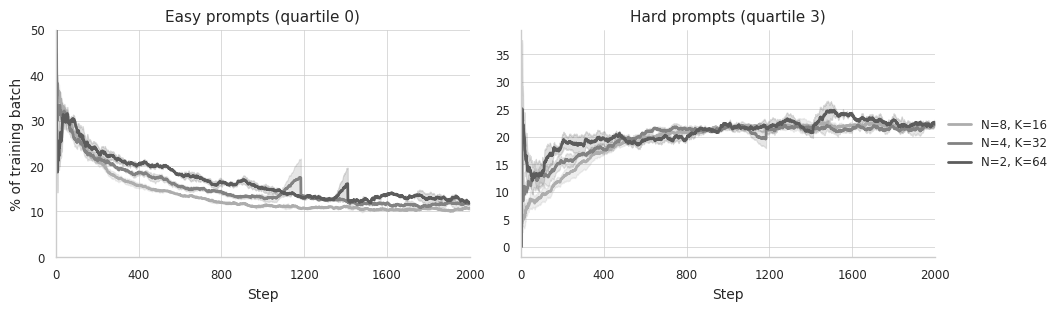

In [28]:
RATIO_EMA_DECAY = 0.995


def build_ratio_df(setting_order: list[str]) -> pd.DataFrame:
    rows = []
    for d in run_data.values():
        spec = d["spec"]
        if spec["excluded"] or spec["setting"] not in setting_order:
            continue
        batch_df = d["batch_df"]
        sub = batch_df[(batch_df["_step"] >= 0) & (batch_df["_step"] <= MAX_STEP)]
        rows.append(pd.DataFrame({
            "setting": spec["setting"], "seed": spec["seed"], "run_id": spec["run_id"],
            "Step": sub["_step"].values, "q0_ratio": sub["q0_ratio"].values, "q3_ratio": sub["q3_ratio"].values,
        }))
    df = pd.concat(rows, ignore_index=True)
    for col in ("q0_ratio", "q3_ratio"):
        df[col] = (
            df.sort_values(["setting", "run_id", "Step"])
            .groupby(["setting", "run_id"], observed=True)[col]
            .transform(lambda s: s.ewm(alpha=1 - RATIO_EMA_DECAY, adjust=True).mean())
        )
    df["setting"] = pd.Categorical(df["setting"], categories=setting_order, ordered=True)
    return df


def plot_ratio(df: pd.DataFrame, setting_order: list[str], palette: dict, out_name: str, q0_title: str = "Easy prompts (quartile 0)", q3_title: str = "Hard prompts (quartile 3)"):
    fig, (ax_q0, ax_q3) = plt.subplots(1, 2, figsize=(10.5, 3.0), constrained_layout=True)
    for ax, ycol, title in [(ax_q0, "q0_ratio", q0_title), (ax_q3, "q3_ratio", q3_title)]:
        sns.lineplot(data=df, x="Step", y=ycol, hue="setting", hue_order=setting_order, palette=palette, errorbar="se", ax=ax)
        ax.set_title(title)
        ax.set_xlabel("Step")
        ax.set_ylabel("% of training batch" if ax is ax_q0 else "")
        ax.set_xlim(0, MAX_STEP)
        ax.set_xticks(range(0, MAX_STEP + 1, 400))
        if ax is ax_q0:
            ax.set_ylim(0, 50)
        sns.despine(ax=ax)
    ax_q3.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    if ax_q0.get_legend() is not None:
        ax_q0.get_legend().remove()
    fig.savefig(OUTPUT_DIR / out_name, bbox_inches="tight")
    return fig, (ax_q0, ax_q3)


baseline_ratio_df = build_ratio_df(BASELINE_SETTING_ORDER)
plot_ratio(baseline_ratio_df, BASELINE_SETTING_ORDER, baseline_ratio_palette, "deepscaler_gradnorm1_baseline_nonzero_prompt_ratio.pdf")
plt.show()

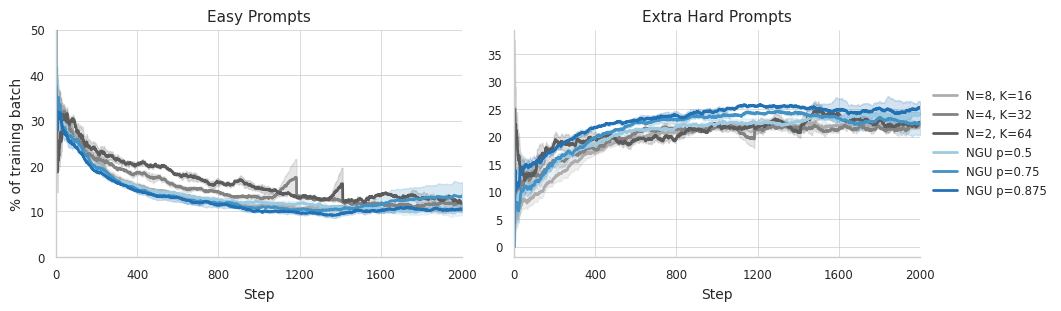

In [29]:
ngu_ratio_df = build_ratio_df(NGU_RATIO_SETTING_ORDER)
plot_ratio(
    ngu_ratio_df, NGU_RATIO_SETTING_ORDER, ngu_ratio_palette, "deepscaler_gradnorm1_ngu_nonzero_prompt_ratio.pdf",
    q0_title="Easy Prompts", q3_title="Extra Hard Prompts",
)
plt.show()

## Training-data prompt difficulty distribution

pass@32 histogram of the DeepScaleR 10k training prompts, colored by
difficulty quartile (mirrors `deepscaler_pass_rate_quartiles.ipynb` and
`deepscaler_ngu_dapo.ipynb`; same training dataset, unaffected by which
sweep we're plotting).


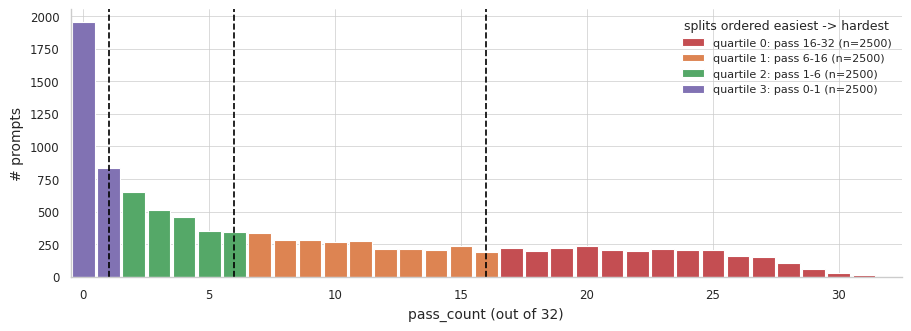

In [29]:
def extract_pass_count(row: pd.Series) -> int:
    pass_count = row.get("pass_count")
    if pd.notna(pass_count):
        return int(pass_count)
    pass_rate = row.get("pass_rate")
    if isinstance(pass_rate, str) and "/" in pass_rate:
        return int(pass_rate.split("/", 1)[0].strip())
    raise ValueError("Row is missing pass_count and parseable pass_rate")


train_difficulty_df = load_dataset(DATASET_REPO, split="train").to_pandas()
train_difficulty_df["pass_count"] = train_difficulty_df.apply(extract_pass_count, axis=1)
train_num_samples = int(train_difficulty_df["num_samples"].iloc[0]) if "num_samples" in train_difficulty_df.columns else 32
train_difficulty_df["quartile"] = train_difficulty_df["dataset"].str.extract(r"quartile(\d+)").astype(int)

pass_values = np.arange(train_num_samples + 1)
counts = train_difficulty_df["pass_count"].value_counts().reindex(pass_values, fill_value=0).sort_index()
maj_quartile = train_difficulty_df.groupby("pass_count")["quartile"].agg(lambda s: s.mode().iloc[0]).reindex(pass_values)
qstats = train_difficulty_df.groupby("quartile")["pass_count"].agg(["min", "max", "count"])
boundaries = [(qstats.loc[q, "min"] + qstats.loc[q + 1, "max"]) / 2.0 for q in range(qstats.index.max())]

quartile_colors = ["#C44E52", "#DD8452", "#55A868", "#8172B3"]  # easiest -> hardest
bar_colors = [quartile_colors[int(q) % 4] if pd.notna(q) else "#cccccc" for q in maj_quartile]

fig, ax = plt.subplots(figsize=(9, 3.2), constrained_layout=True)
ax.bar(pass_values, counts.values, width=0.9, color=bar_colors, edgecolor="white")
ymax = ax.get_ylim()[1]
for b in boundaries:
    ax.axvline(b, color="black", linestyle="--", linewidth=1.2)
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=quartile_colors[q % 4],
                  label=f"quartile {q}: pass {qstats.loc[q, 'min']}-{qstats.loc[q, 'max']} (n={qstats.loc[q, 'count']})")
    for q in sorted(train_difficulty_df["quartile"].unique())
]
ax.legend(handles=legend_handles, title="splits ordered easiest -> hardest", frameon=False, fontsize=8)
ax.set_xlabel(f"pass_count (out of {train_num_samples})")
ax.set_ylabel("# prompts")
ax.set_xlim(-0.5, train_num_samples + 0.5)
sns.despine(ax=ax)
fig.savefig(OUTPUT_DIR / "deepscaler_train_prompt_difficulty.pdf", bbox_inches="tight")
plt.show()


## Eval prompt difficulty distribution (AIME + BRUMO)

Same style as the training-data histogram above, but for the AIME 2025 +
BRUMO 2025 eval prompts. Unlike the per-competition bucket plots elsewhere in
this notebook, this treats AIME and BRUMO as **one pooled set of 60
questions** and buckets them jointly by pass_count (out of
`DIFFICULTY_NUM_SAMPLES`) from the `w47m67sf`-derived initial-model
solve-rate tables -- `difficulty_assignments_combined_df`, built above in the
"Difficulty buckets" section as a single hard/medium/easy split over the
pooled set (not AIME's and BRUMO's independent splits merged together).


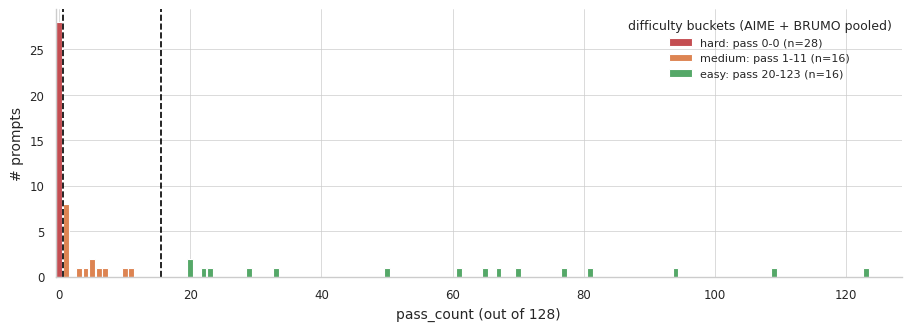

In [30]:
DIFFICULTY_BUCKET_COLORS = {"hard": "#C44E52", "medium": "#DD8452", "easy": "#55A868"}


def plot_eval_prompt_difficulty(df: pd.DataFrame, ax):
    pass_values = np.arange(DIFFICULTY_NUM_SAMPLES + 1)
    counts = df["pass_count"].value_counts().reindex(pass_values, fill_value=0).sort_index()
    maj_difficulty = df.groupby("pass_count")["difficulty"].agg(lambda s: s.mode().iloc[0]).reindex(pass_values)
    dstats = df.groupby("difficulty", observed=True)["pass_count"].agg(["min", "max", "count"]).reindex(DIFFICULTY_ORDER)
    bar_colors = [DIFFICULTY_BUCKET_COLORS[d] if pd.notna(d) else "#cccccc" for d in maj_difficulty]

    ax.bar(pass_values, counts.values, width=0.9, color=bar_colors, edgecolor="white")
    for lo, hi in zip(DIFFICULTY_ORDER[:-1], DIFFICULTY_ORDER[1:]):
        if pd.notna(dstats.loc[lo, "max"]) and pd.notna(dstats.loc[hi, "min"]):
            ax.axvline((dstats.loc[lo, "max"] + dstats.loc[hi, "min"]) / 2.0, color="black", linestyle="--", linewidth=1.2)

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=DIFFICULTY_BUCKET_COLORS[d],
                      label=f"{d}: pass {int(dstats.loc[d, 'min'])}-{int(dstats.loc[d, 'max'])} (n={int(dstats.loc[d, 'count'])})")
        for d in DIFFICULTY_ORDER
    ]
    ax.legend(handles=legend_handles, title="difficulty buckets (AIME + BRUMO pooled)", frameon=False, fontsize=8)
    ax.set_xlabel(f"pass_count (out of {DIFFICULTY_NUM_SAMPLES})")
    ax.set_ylabel("# prompts")
    ax.set_xlim(-0.5, DIFFICULTY_NUM_SAMPLES + 0.5)
    sns.despine(ax=ax)


fig, ax = plt.subplots(figsize=(9, 3.2), constrained_layout=True)
plot_eval_prompt_difficulty(difficulty_assignments_combined_df, ax)
fig.savefig(OUTPUT_DIR / "deepscaler_eval_prompt_difficulty.pdf", bbox_inches="tight")
plt.show()

## Summary table: eval scores by setting, at each run's own best step

Each setting now has 2-3 seeds (see run registry above); the "Avg ± Std"
column reports the mean and sample std across the *included* seeds for that
setting (n shown in parentheses). AIME and BRUMO are broken out as separate
top-level columns (via `EVAL_DATASETS`), each with the same
seed-columns-plus-`Avg ± Std` layout as `deepscaler_ngu_dapo.ipynb`'s
single-dataset table -- easy to extend with more eval datasets later by
adding to `EVAL_DATASETS` and to `best_step_rows` above. A final "Total"
column averages AIME and BRUMO pass@1 per seed (computed from `best_row`
directly in `best_step_rows`, so it's an average of the two raw pass@1
values, not of the already-rounded display strings).


In [31]:
EVAL_TABLE_SECTIONS = [
    ("GRPO Baseline", BASELINE_SETTING_ORDER),
    ("NGU", NGU_SETTING_ORDER),
    ("Sampling Baseline", ADA_EST_SETTING_ORDER),
]


def build_eval_table(dataset_suffix: str) -> pd.DataFrame:
    rows = []
    for group_name, settings in EVAL_TABLE_SECTIONS:
        for setting in settings:
            sub = best_step_df[best_step_df["setting"] == setting].sort_values("seed")
            row = {"Group": group_name, "Setting": setting}
            for _, seed_row in sub.iterrows():
                pct = float(seed_row[f"best_pass_at_1_{dataset_suffix}"]) * 100
                label = f"Seed {int(seed_row['seed'])}"
                row[label] = f"{pct:.1f}*" if seed_row["excluded"] else f"{pct:.1f}"

            included_values = sub.loc[~sub["excluded"], f"best_pass_at_1_{dataset_suffix}"].astype(float) * 100
            n = len(included_values)
            mean, std = included_values.mean(), included_values.std(ddof=1)
            row["Avg ± Std"] = f"{mean:.1f} ± {std:.1f} (n={n})" if n > 1 else f"{mean:.1f} (n={n})"
            rows.append(row)

    df = pd.DataFrame(rows)
    seed_cols = sorted((c for c in df.columns if c.startswith("Seed ")), key=lambda c: int(c.split(" ")[1]))
    return df[["Group", "Setting", *seed_cols, "Avg ± Std"]].set_index(["Group", "Setting"])


SUMMARY_TABLE_COLUMNS = {**EVAL_DATASETS, "Total": "total"}  # "Total" = per-seed average of AIME and BRUMO pass@1

eval_summary_df = pd.concat(
    {label: build_eval_table(suffix) for label, suffix in SUMMARY_TABLE_COLUMNS.items()},
    axis=1,
)
eval_summary_df.to_csv(OUTPUT_DIR / "deepscaler_gradnorm1_eval_summary.csv")
print("pass@1 (%) at each run's own best step, by eval dataset; '*' marks a seed excluded from Avg ± Std.")
display(eval_summary_df)


pass@1 (%) at each run's own best step, by eval dataset; '*' marks a seed excluded from Avg ± Std.


AIME                                  BRUMO                                  Total                \
                                                Seed 1 Seed 2 Seed 3         Avg ± Std Seed 1 Seed 2 Seed 3         Avg ± Std Seed 1 Seed 2 Seed 3   
Group             Setting                                                                                                                            
GRPO Baseline     N=8, K=16                       21.7   19.7   18.6  20.0 ± 1.5 (n=3)   29.1   31.1   28.5  29.6 ± 1.4 (n=3)   25.4   25.4   23.6   
                  N=4, K=32                       21.7   20.0   22.6  21.4 ± 1.3 (n=3)   29.7   29.5   28.3  29.2 ± 0.7 (n=3)   25.7   24.7   25.5   
                  N=2, K=64                       21.4   19.8   19.7  20.3 ± 0.9 (n=3)   28.7   28.1   29.5  28.8 ± 0.7 (n=3)   25.1   24.0   24.6   
NGU               N=8, K=16                       21.7   19.7   18.6  20.0 ± 1.5 (n=3)   29.1   31.1   28.5  29.6 ± 1.4 (n=3)   25.4   25.4   23.6   
                  NGU p=0.5                       22.5   21.1   22.3  22.0 ± 0.7 (n=3)   30.2   31.7   28.5  30.1 ± 1.6 (n=3)   26.4   26.4   25.4   
                  NGU p=0.75                      22.4   22.6   18.9  21.3 ± 2.1 (n=3)   30.0   31.8   32.9  31.6 ± 1.5 (n=3)   26.2   27.2   25.9   
                  NGU p=0.875                     21.7   22.0   21.8  21.8 ± 0.2 (n=3)   32.1   29.8   31.9  31.2 ± 1.3 (n=3)   26.9   25.9   26.8   
Sampling Baseline Sampling Curriculum (GVM/Est)   20.4   21.4   21.9  21.2 ± 0.7 (n=3)   28.7   28.6   29.7  29.0 ± 0.6 (n=3)   24.6   25.0   25.8   

                                                                   
                                                        Avg ± Std  
Group             Setting                                          
GRPO Baseline     N=8, K=16                      24.8 ± 1.0 (n=3)  
                  N=4, K=32                      25.3 ± 0.5 (n=3)  
                  N=2, K=64                      24.5 ± 0.5 (n=3)  
NGU               N=8, K=16                      24.8 ± 1.0 (n=3)  
                  NGU p=0.5                      26.1 ± 0.6 (n=3)  
                  NGU p=0.75                     26.4 ± 0.7 (n=3)  
                  NGU p=0.875                    26.5 ± 0.6 (n=3)  
Sampling Baseline Sampling Curriculum (GVM/Est)  25.1 ± 0.6 (n=3)

In [32]:
eval_summary_df

AIME                                  BRUMO                                  Total                \
                                                Seed 1 Seed 2 Seed 3         Avg ± Std Seed 1 Seed 2 Seed 3         Avg ± Std Seed 1 Seed 2 Seed 3   
Group             Setting                                                                                                                            
GRPO Baseline     N=8, K=16                       21.7   19.7   18.6  20.0 ± 1.5 (n=3)   29.1   31.1   28.5  29.6 ± 1.4 (n=3)   25.4   25.4   23.6   
                  N=4, K=32                       21.7   20.0   22.6  21.4 ± 1.3 (n=3)   29.7   29.5   28.3  29.2 ± 0.7 (n=3)   25.7   24.7   25.5   
                  N=2, K=64                       21.4   19.8   19.7  20.3 ± 0.9 (n=3)   28.7   28.1   29.5  28.8 ± 0.7 (n=3)   25.1   24.0   24.6   
NGU               N=8, K=16                       21.7   19.7   18.6  20.0 ± 1.5 (n=3)   29.1   31.1   28.5  29.6 ± 1.4 (n=3)   25.4   25.4   23.6   
                  NGU p=0.5                       22.5   21.1   22.3  22.0 ± 0.7 (n=3)   30.2   31.7   28.5  30.1 ± 1.6 (n=3)   26.4   26.4   25.4   
                  NGU p=0.75                      22.4   22.6   18.9  21.3 ± 2.1 (n=3)   30.0   31.8   32.9  31.6 ± 1.5 (n=3)   26.2   27.2   25.9   
                  NGU p=0.875                     21.7   22.0   21.8  21.8 ± 0.2 (n=3)   32.1   29.8   31.9  31.2 ± 1.3 (n=3)   26.9   25.9   26.8   
Sampling Baseline Sampling Curriculum (GVM/Est)   20.4   21.4   21.9  21.2 ± 0.7 (n=3)   28.7   28.6   29.7  29.0 ± 0.6 (n=3)   24.6   25.0   25.8   

                                                                   
                                                        Avg ± Std  
Group             Setting                                          
GRPO Baseline     N=8, K=16                      24.8 ± 1.0 (n=3)  
                  N=4, K=32                      25.3 ± 0.5 (n=3)  
                  N=2, K=64                      24.5 ± 0.5 (n=3)  
NGU               N=8, K=16                      24.8 ± 1.0 (n=3)  
                  NGU p=0.5                      26.1 ± 0.6 (n=3)  
                  NGU p=0.75                     26.4 ± 0.7 (n=3)  
                  NGU p=0.875                    26.5 ± 0.6 (n=3)  
Sampling Baseline Sampling Curriculum (GVM/Est)  25.1 ± 0.6 (n=3)

## Summary table: pass@1 improvement over `initial_eval`, by difficulty bucket

Same `improvement` metric as `deepscaler_gradnorm1_ngu_pass_at_1_improvement_by_difficulty_combined.pdf` above (pass@1 minus `initial_eval`'s pass@1 in that Combined AIME+BRUMO difficulty bucket, in percentage points), collapsed into a table: mean ± std across the *included* seeds for each setting, with `hard`/`medium`/`easy` as columns. Covers all three baseline N/K settings (`GRPO Baseline`), the NGU p sweep (`NGU`), and the `Sampling Baseline` group (`Sampling Curriculum (GVM/Est)` + `Reinforce-Ada-Seq-Pos`).


In [ ]:
NGU_ONLY_SETTING_ORDER = ["NGU p=0.5", "NGU p=0.75", "NGU p=0.875"]  # NGU p sweep without the shared N=8,K=16 baseline row
IMPROVEMENT_TABLE_COLUMN_ORDER = ["easy", "medium", "hard"]  # this table reads easy -> hard, left to right
IMPROVEMENT_TABLE_SECTIONS = [
    ("GRPO Baseline", BASELINE_SETTING_ORDER),
    ("NGU", NGU_ONLY_SETTING_ORDER),
    ("Sampling Baseline", ADA_EST_SETTING_ORDER + REINFORCE_ADA_SEQ_POS_SETTING_ORDER),
]


def build_improvement_summary_table(dataset_name: str = "Combined") -> pd.DataFrame:
    setting_order = [s for _, settings in IMPROVEMENT_TABLE_SECTIONS for s in settings]
    bucket_df = build_bucket_accuracy_df(setting_order, dataset_name)
    initial_lookup = INITIAL_BUCKET_PASS_AT_1[dataset_name]
    bucket_df["improvement"] = (
        bucket_df["pass_at_1"].astype(float) - bucket_df["difficulty"].map(initial_lookup).astype(float)
    ) * 100

    rows = []
    for group_name, settings in IMPROVEMENT_TABLE_SECTIONS:
        for setting in settings:
            sub = bucket_df[bucket_df["setting"] == setting]
            row = {"Group": group_name, "Setting": setting}
            for difficulty in DIFFICULTY_ORDER:
                values = sub.loc[sub["difficulty"] == difficulty, "improvement"]
                mean, std, n = values.mean(), values.std(ddof=1), len(values)
                row[difficulty.capitalize()] = f"{mean:.1f} ± {std:.1f}" if n > 1 else f"{mean:.1f}"
            rows.append(row)

    df = pd.DataFrame(rows).set_index(["Group", "Setting"])
    return df[[d.capitalize() for d in IMPROVEMENT_TABLE_COLUMN_ORDER]]


improvement_summary_combined_df = build_improvement_summary_table("Combined")
improvement_summary_combined_df.to_csv(OUTPUT_DIR / "deepscaler_gradnorm1_improvement_by_difficulty_summary_combined.csv")
print("pass@1 (%) improvement over initial_eval vs. difficulty bucket (Combined AIME+BRUMO), mean ± std across seeds")
display(improvement_summary_combined_df)


pass@1 (%) improvement over initial_eval vs. difficulty bucket (Combined AIME+BRUMO), mean ± std across seeds


Easy      Medium       Hard
Group             Setting                                                         
GRPO Baseline     N=8, K=16                      26.8 ± 2.6  14.5 ± 3.6  1.6 ± 0.3
                  N=4, K=32                      26.0 ± 2.5  15.4 ± 1.8  2.5 ± 1.1
                  N=2, K=64                      23.3 ± 1.9  15.3 ± 1.5  2.5 ± 0.2
NGU               NGU p=0.5                      25.1 ± 2.3  17.9 ± 2.2  3.3 ± 1.9
                  NGU p=0.75                     28.1 ± 0.2  16.8 ± 3.3  3.0 ± 1.2
                  NGU p=0.875                    26.8 ± 1.7  16.3 ± 0.9  4.3 ± 1.2
Sampling Baseline Sampling Curriculum (GVM/Est)  22.7 ± 1.6  15.5 ± 1.4  4.0 ± 1.1
                  Reinforce-Ada-Seq-Pos                 0.8         0.8        0.0

Copyable Markdown source for the table above (printed as plain text so it can be selected/copied directly, e.g. for pasting into a GitHub PR or `research.md`):


In [ ]:
def df_to_markdown(df: pd.DataFrame) -> str:
    # Plain pandas/str implementation (no `tabulate` dependency) so this works in any kernel.
    header = list(df.columns)
    rows = df.astype(str).values.tolist()
    widths = [max(len(h), *(len(r[i]) for r in rows)) if rows else len(h) for i, h in enumerate(header)]
    def fmt_row(cells: list[str]) -> str:
        return "| " + " | ".join(c.ljust(w) for c, w in zip(cells, widths)) + " |"
    lines = [fmt_row(header), fmt_row(["-" * w for w in widths])]
    lines += [fmt_row(r) for r in rows]
    return "\n".join(lines)


print(df_to_markdown(improvement_summary_combined_df.reset_index()))


| Group             | Setting                       | Easy       | Medium     | Hard      |
| ----------------- | ----------------------------- | ---------- | ---------- | --------- |
| GRPO Baseline     | N=8, K=16                     | 26.8 ± 2.6 | 14.5 ± 3.6 | 1.6 ± 0.3 |
| GRPO Baseline     | N=4, K=32                     | 26.0 ± 2.5 | 15.4 ± 1.8 | 2.5 ± 1.1 |
| GRPO Baseline     | N=2, K=64                     | 23.3 ± 1.9 | 15.3 ± 1.5 | 2.5 ± 0.2 |
| NGU               | NGU p=0.5                     | 25.1 ± 2.3 | 17.9 ± 2.2 | 3.3 ± 1.9 |
| NGU               | NGU p=0.75                    | 28.1 ± 0.2 | 16.8 ± 3.3 | 3.0 ± 1.2 |
| NGU               | NGU p=0.875                   | 26.8 ± 1.7 | 16.3 ± 0.9 | 4.3 ± 1.2 |
| Sampling Baseline | Sampling Curriculum (GVM/Est) | 22.7 ± 1.6 | 15.5 ± 1.4 | 4.0 ± 1.1 |
| Sampling Baseline | Reinforce-Ada-Seq-Pos         | 0.8        | 0.8        | 0.0       |
